# Customer experience EDA
Tài liệu này tập trung phân tích trải nghiệm khách hàng thông qua dữ liệu trả hàng và đánh giá sản phẩm.

### Prepare libraries and load data:

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Loading data...")
# Master
df_pduct = pd.read_parquet('../dataset/cleaned/products.parquet')
df_cus = pd.read_parquet('../dataset/cleaned/customers.parquet')
df_pmot = pd.read_parquet('../dataset/cleaned/promotions.parquet')
df_geo = pd.read_parquet('../dataset/cleaned/geography.parquet')

# Transaction
df_ord = pd.read_parquet('../dataset/cleaned/orders.parquet')
df_item = pd.read_parquet('../dataset/cleaned/order_items.parquet')
df_ship = pd.read_parquet('../dataset/cleaned/shipments.parquet')
df_ret = pd.read_parquet('../dataset/cleaned/returns.parquet')
df_rev = pd.read_parquet('../dataset/cleaned/reviews.parquet')

# Analytical
df_sale = pd.read_parquet('../dataset/cleaned/sales.parquet')
#df_submit = pd.read_parquet('../dataset/sample_submission.csv')

# Operational
df_inv = pd.read_parquet('../dataset/cleaned/inventory.parquet')
df_web = pd.read_parquet('../dataset/cleaned/web_traffic.parquet')
print("Load data successfully")

Loading data...
Load data successfully


## Phân tích tập trung return

### Phân tích đơn biến return

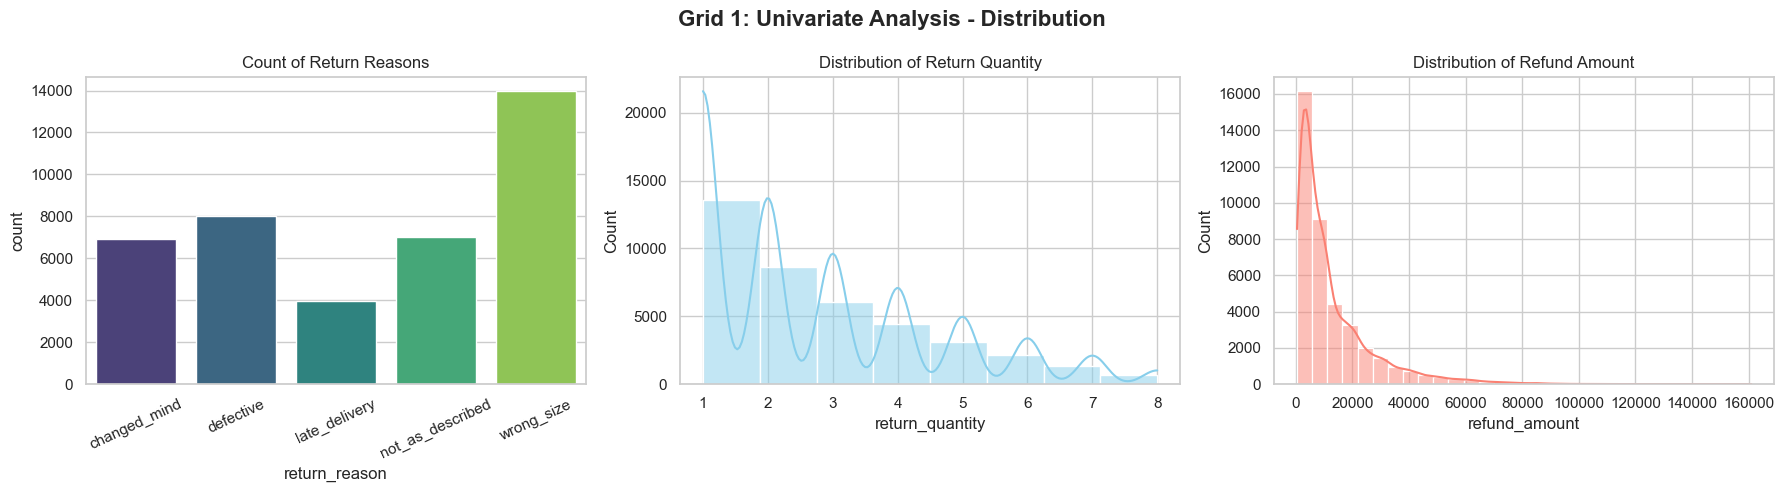

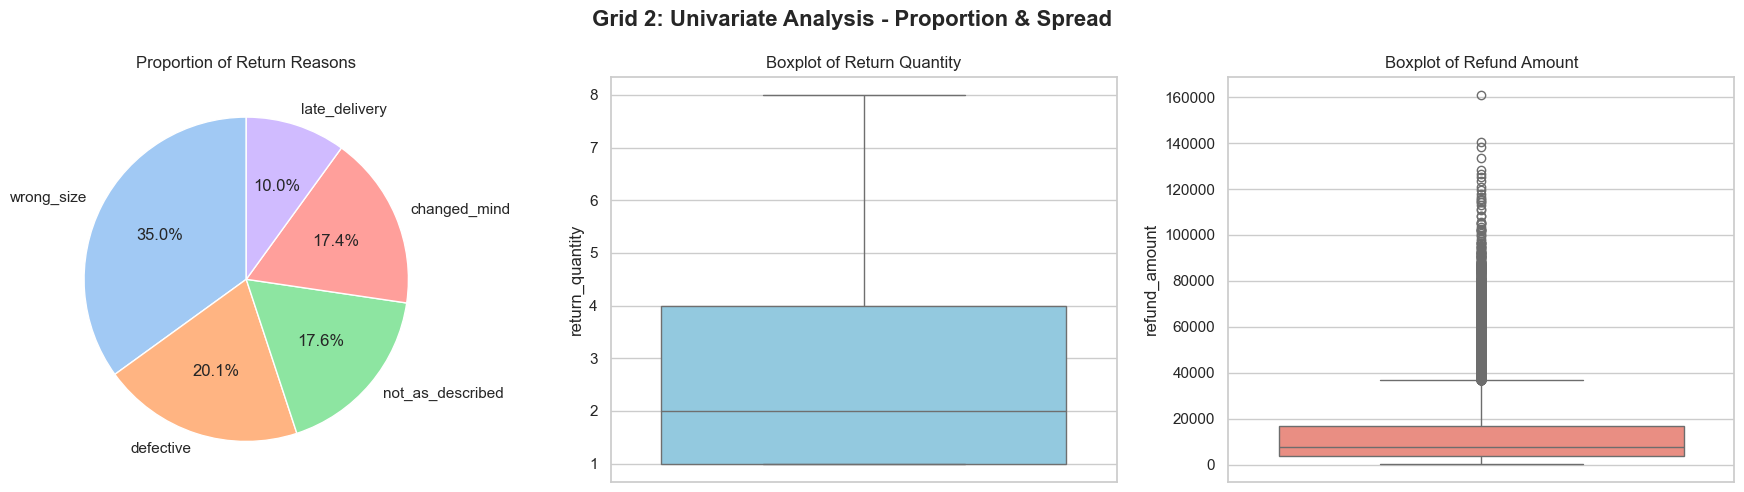

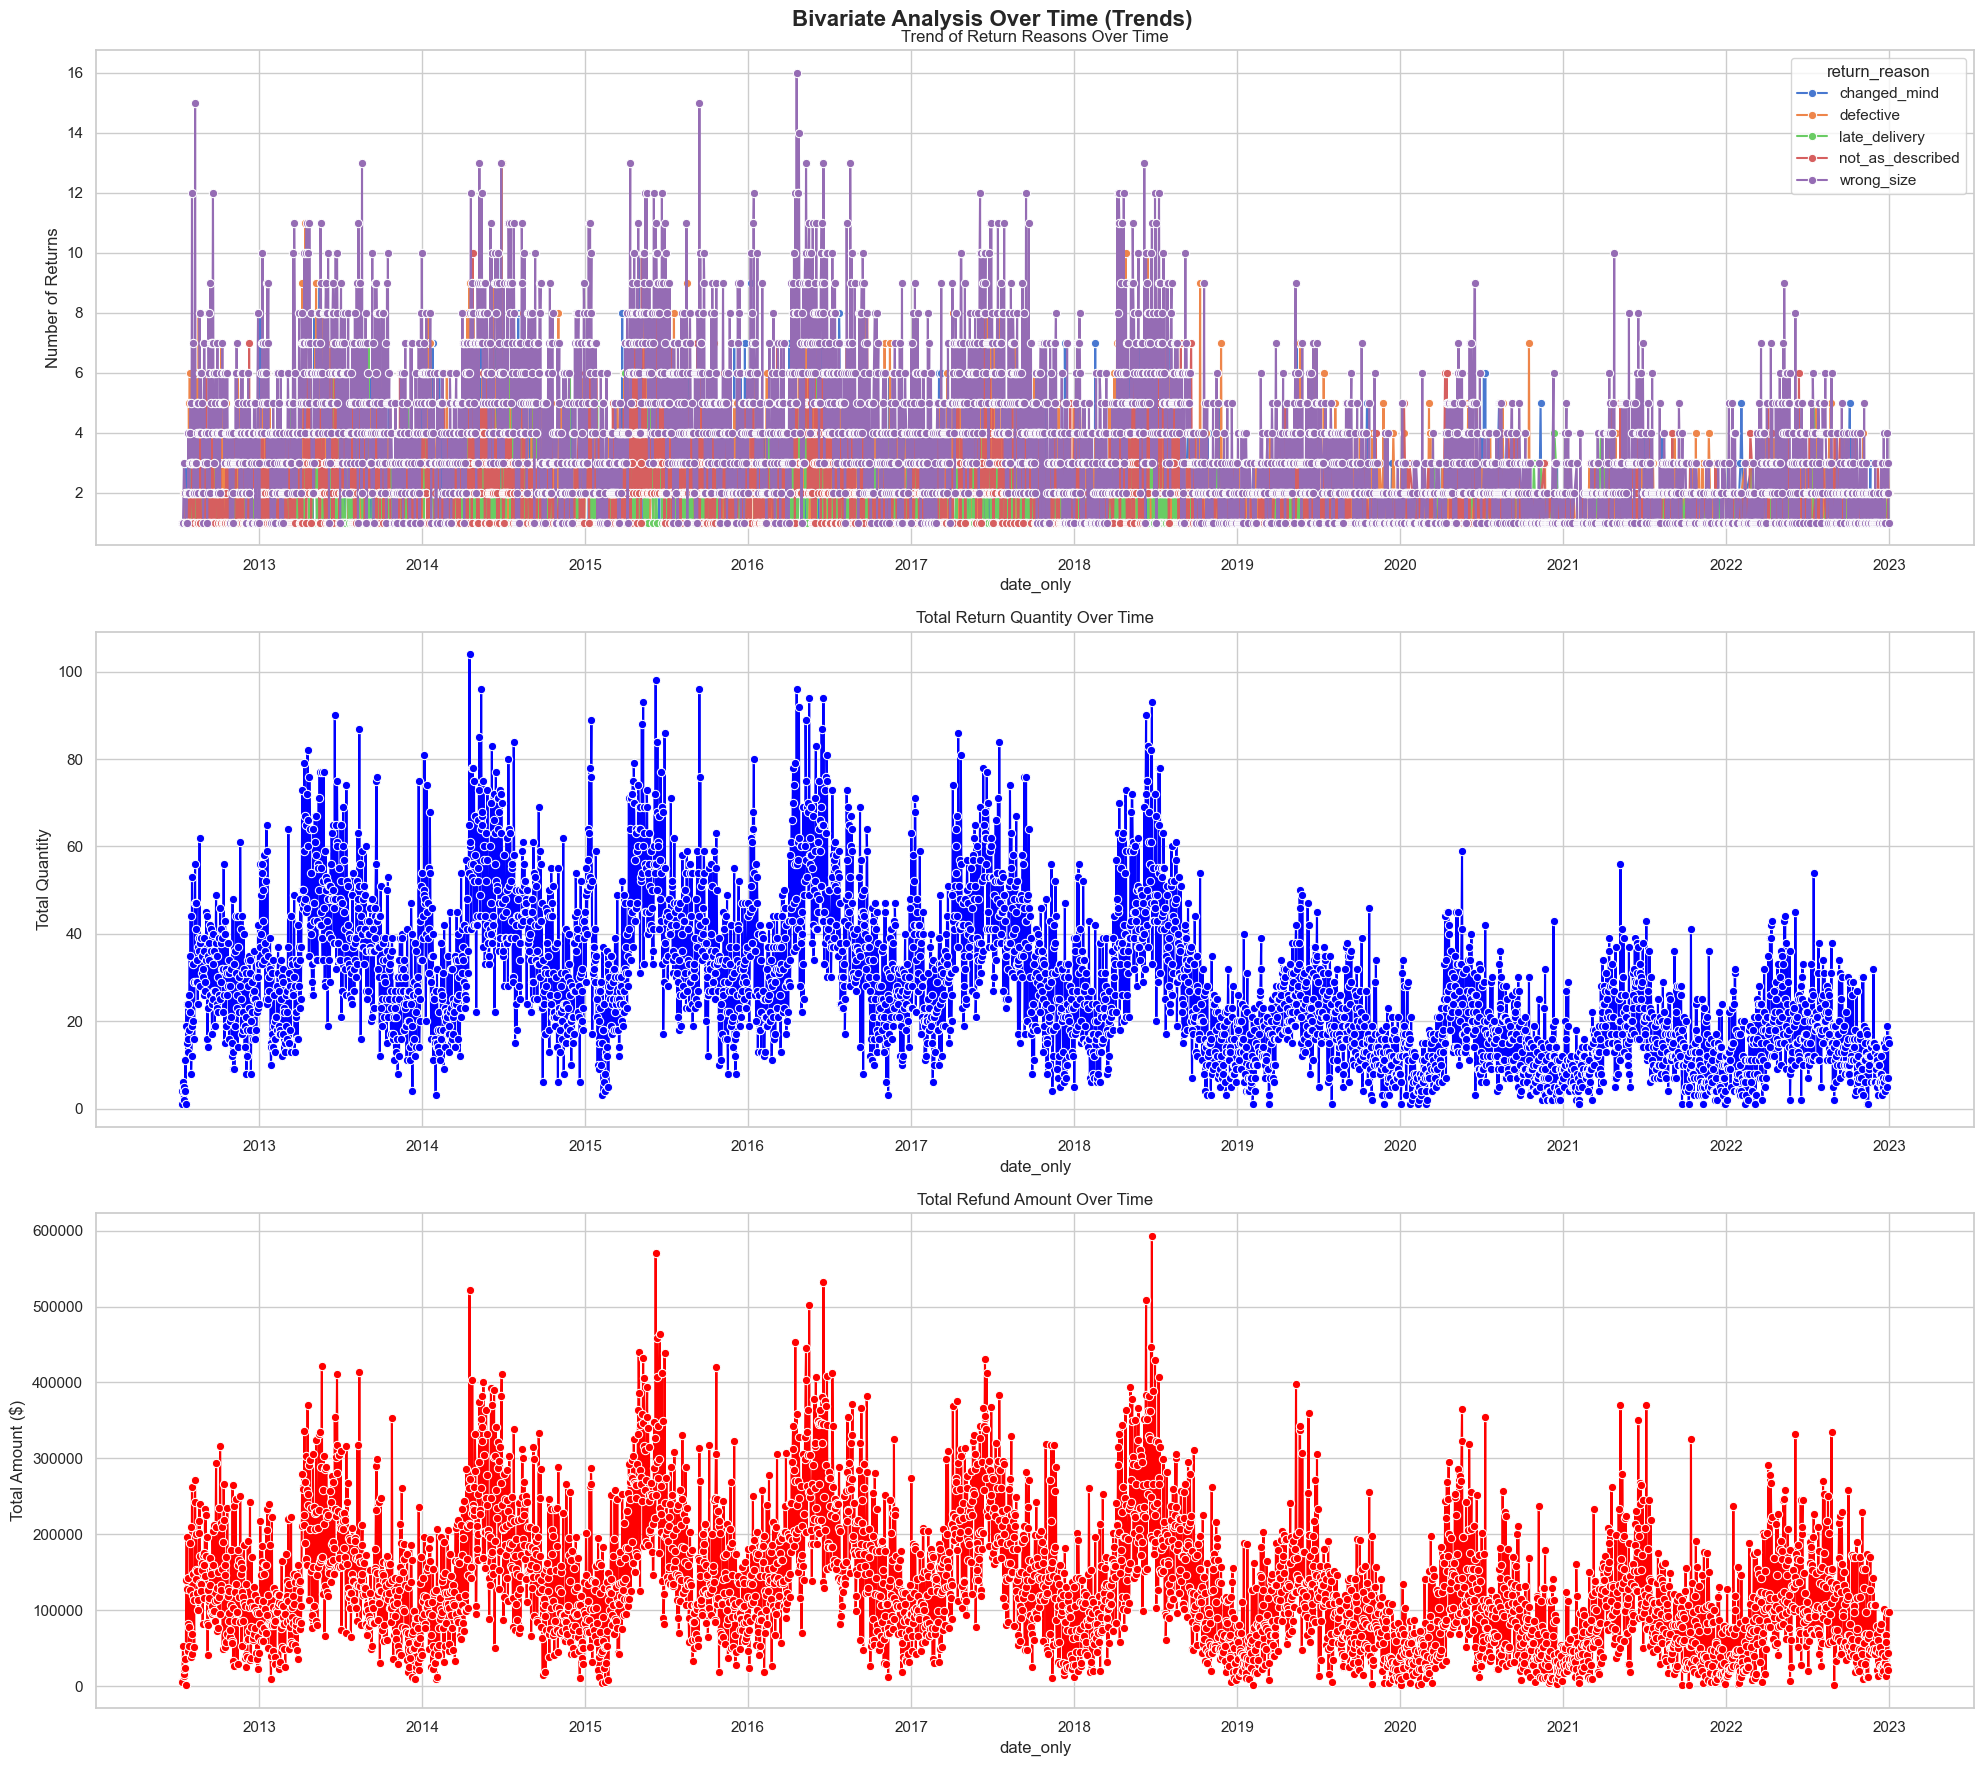

In [6]:

# UNIVARIATE ANALYSIS
# Lưới 1: Distribution: Bar Plot & Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Grid 1: Univariate Analysis - Distribution', fontsize=16, fontweight='bold')

sns.countplot(data=df_ret, x='return_reason', hue='return_reason', legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Count of Return Reasons')
axes[0].tick_params(axis='x', rotation=25)

sns.histplot(data=df_ret, x='return_quantity', bins=8, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Return Quantity')

sns.histplot(data=df_ret, x='refund_amount', bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribution of Refund Amount')

plt.tight_layout()
plt.show()

# Lưới 2: Proportion & Spread: Pie & Boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Grid 2: Univariate Analysis - Proportion & Spread', fontsize=16, fontweight='bold')

reason_counts = df_ret['return_reason'].value_counts()
axes[0].pie(reason_counts, labels=reason_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
axes[0].set_title('Proportion of Return Reasons')

sns.boxplot(data=df_ret, y='return_quantity', ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot of Return Quantity')

sns.boxplot(data=df_ret, y='refund_amount', ax=axes[2], color='salmon')
axes[2].set_title('Boxplot of Refund Amount')

plt.tight_layout()
plt.show()



# BIVARIATE ANALYSIS OVER TIME
import matplotlib.dates as mdates
df_ret['date_only'] = df_ret['return_date'].dt.date

fig, axes = plt.subplots(3, 1, figsize=(20, 18))
fig.suptitle('Bivariate Analysis Over Time (Trends)', fontsize=16, fontweight='bold')

reason_trend = df_ret.groupby(['date_only', 'return_reason'], observed=True).size().reset_index(name='count')
sns.lineplot(data=reason_trend, x='date_only', y='count', hue='return_reason', marker='o', ax=axes[0])
axes[0].set_title('Trend of Return Reasons Over Time')
axes[0].set_ylabel('Number of Returns')

quantity_trend = df_ret.groupby('date_only', observed=True)['return_quantity'].sum().reset_index()
sns.lineplot(data=quantity_trend, x='date_only', y='return_quantity', color='blue', marker='o', ax=axes[1])
axes[1].set_title('Total Return Quantity Over Time')
axes[1].set_ylabel('Total Quantity')

amount_trend = df_ret.groupby('date_only', observed=True)['refund_amount'].sum().reset_index()
sns.lineplot(data=amount_trend, x='date_only', y='refund_amount', color='red', marker='o', ax=axes[2])
axes[2].set_title('Total Refund Amount Over Time')
axes[2].set_ylabel('Total Amount ($)')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x')

plt.tight_layout()
plt.show()

### Phân tích đa biến return

In [7]:
df_master_ret = df_ret.merge(df_item, on=['order_id', 'product_id'], how='left')
df_master_ret = df_master_ret.merge(df_ord, on=['order_id'], how='left')
df_master_ret = df_master_ret.merge(df_pduct, on=['product_id'], how='left')
df_master_ret = df_master_ret.merge(df_ship, on=['order_id'], how='left')
df_master_ret = df_master_ret.merge(df_geo, on=['zip'], how='left')
df_master_ret = df_master_ret.merge(df_cus.drop(columns=['zip', 'city']), on=['customer_id'], how='left')

df_master_ret.info()
df_master_ret.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39943 entries, 0 to 39942
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   return_id            39943 non-null  string        
 1   order_id             39943 non-null  string        
 2   product_id           39943 non-null  string        
 3   return_date          39943 non-null  datetime64[ns]
 4   return_reason        39943 non-null  category      
 5   return_quantity      39943 non-null  int64         
 6   refund_amount        39943 non-null  float64       
 7   date_only            39943 non-null  object        
 8   quantity             39943 non-null  int64         
 9   unit_price           39943 non-null  float64       
 10  discount_amount      39943 non-null  float64       
 11  promo_id             39943 non-null  string        
 12  promo_id_2           39943 non-null  string        
 13  order_date           39943 non-

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,date_only,quantity,unit_price,...,ship_date,delivery_date,shipping_fee,city,region,district,signup_date,gender,age_group,acquisition_channel
29956,RET-038539,615623,544,2018-08-13,defective,3,26006.60,2018-08-13,5,9217.06,...,2018-07-18,2018-07-25,1.79,Nha Trang,Central,District #25,2021-04-15,Female,35-44,paid_search
19499,RET-025078,394051,2332,2016-06-07,defective,3,16499.63,2016-06-07,5,5875.21,...,2016-05-24,2016-05-27,1.38,Vung Tau,West,District #36,2022-12-20,Female,18-24,paid_search
2954,RET-003813,58066,826,2013-04-18,wrong_size,5,48482.50,2013-04-18,7,11215.53,...,2013-03-27,2013-04-03,1.20,Nha Trang,Central,District #32,2017-12-17,Male,18-24,referral


In [8]:
df_ret_pmot = df_master_ret[['return_id', 'return_reason', 'return_quantity', 'quantity', 'discount_amount', 'promo_id', 'promo_id_2']]
df_ret_pduct = df_master_ret[['return_id', 'return_reason', 'return_quantity', 'refund_amount', 'product_id', 'product_name', 'category', 'segment', 'size']]
df_ret_ord_cus = df_master_ret[['return_id', 'return_reason', 'return_quantity', 'order_id', 'payment_method', 'device_type', 'order_source', 'customer_id', 'age_group', 'region']]
df_ret_ship = df_master_ret[['return_id', 'return_reason', 'return_date', 'order_date', 'ship_date', 'delivery_date', 'shipping_fee']]

eda_return_list = [df_ret_pmot, df_ret_pduct, df_ret_ord_cus, df_ret_ship]

for df in eda_return_list: # Khuyên dùng Dictionary như đã trao đổi
    print(f"\n{'='*50}")
    df.info()
    print("-" * 30)
    for col in df.columns:
        is_category = df[col].dtype.name == 'category'
        is_boolean = pd.api.types.is_bool_dtype(df[col])
        
        if is_category or is_boolean:
            print(f"\n>>> Đếm số lượng cột: '{col}'")
            counts = df[col].value_counts()
            percentages = df[col].value_counts(normalize=True) * 100
            
            summary_df = pd.DataFrame({'Số lượng': counts, 'Tỷ lệ (%)': percentages.round(2)})
            print(summary_df)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39943 entries, 0 to 39942
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   return_id        39943 non-null  string  
 1   return_reason    39943 non-null  category
 2   return_quantity  39943 non-null  int64   
 3   quantity         39943 non-null  int64   
 4   discount_amount  39943 non-null  float64 
 5   promo_id         39943 non-null  string  
 6   promo_id_2       39943 non-null  string  
dtypes: category(1), float64(1), int64(2), string(3)
memory usage: 1.9 MB
------------------------------

>>> Đếm số lượng cột: 'return_reason'
                  Số lượng  Tỷ lệ (%)
return_reason                        
wrong_size           13970      34.97
defective             8020      20.08
not_as_described      7036      17.62
changed_mind          6931      17.35
late_delivery         3986       9.98

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39943 e

#### return with promotion

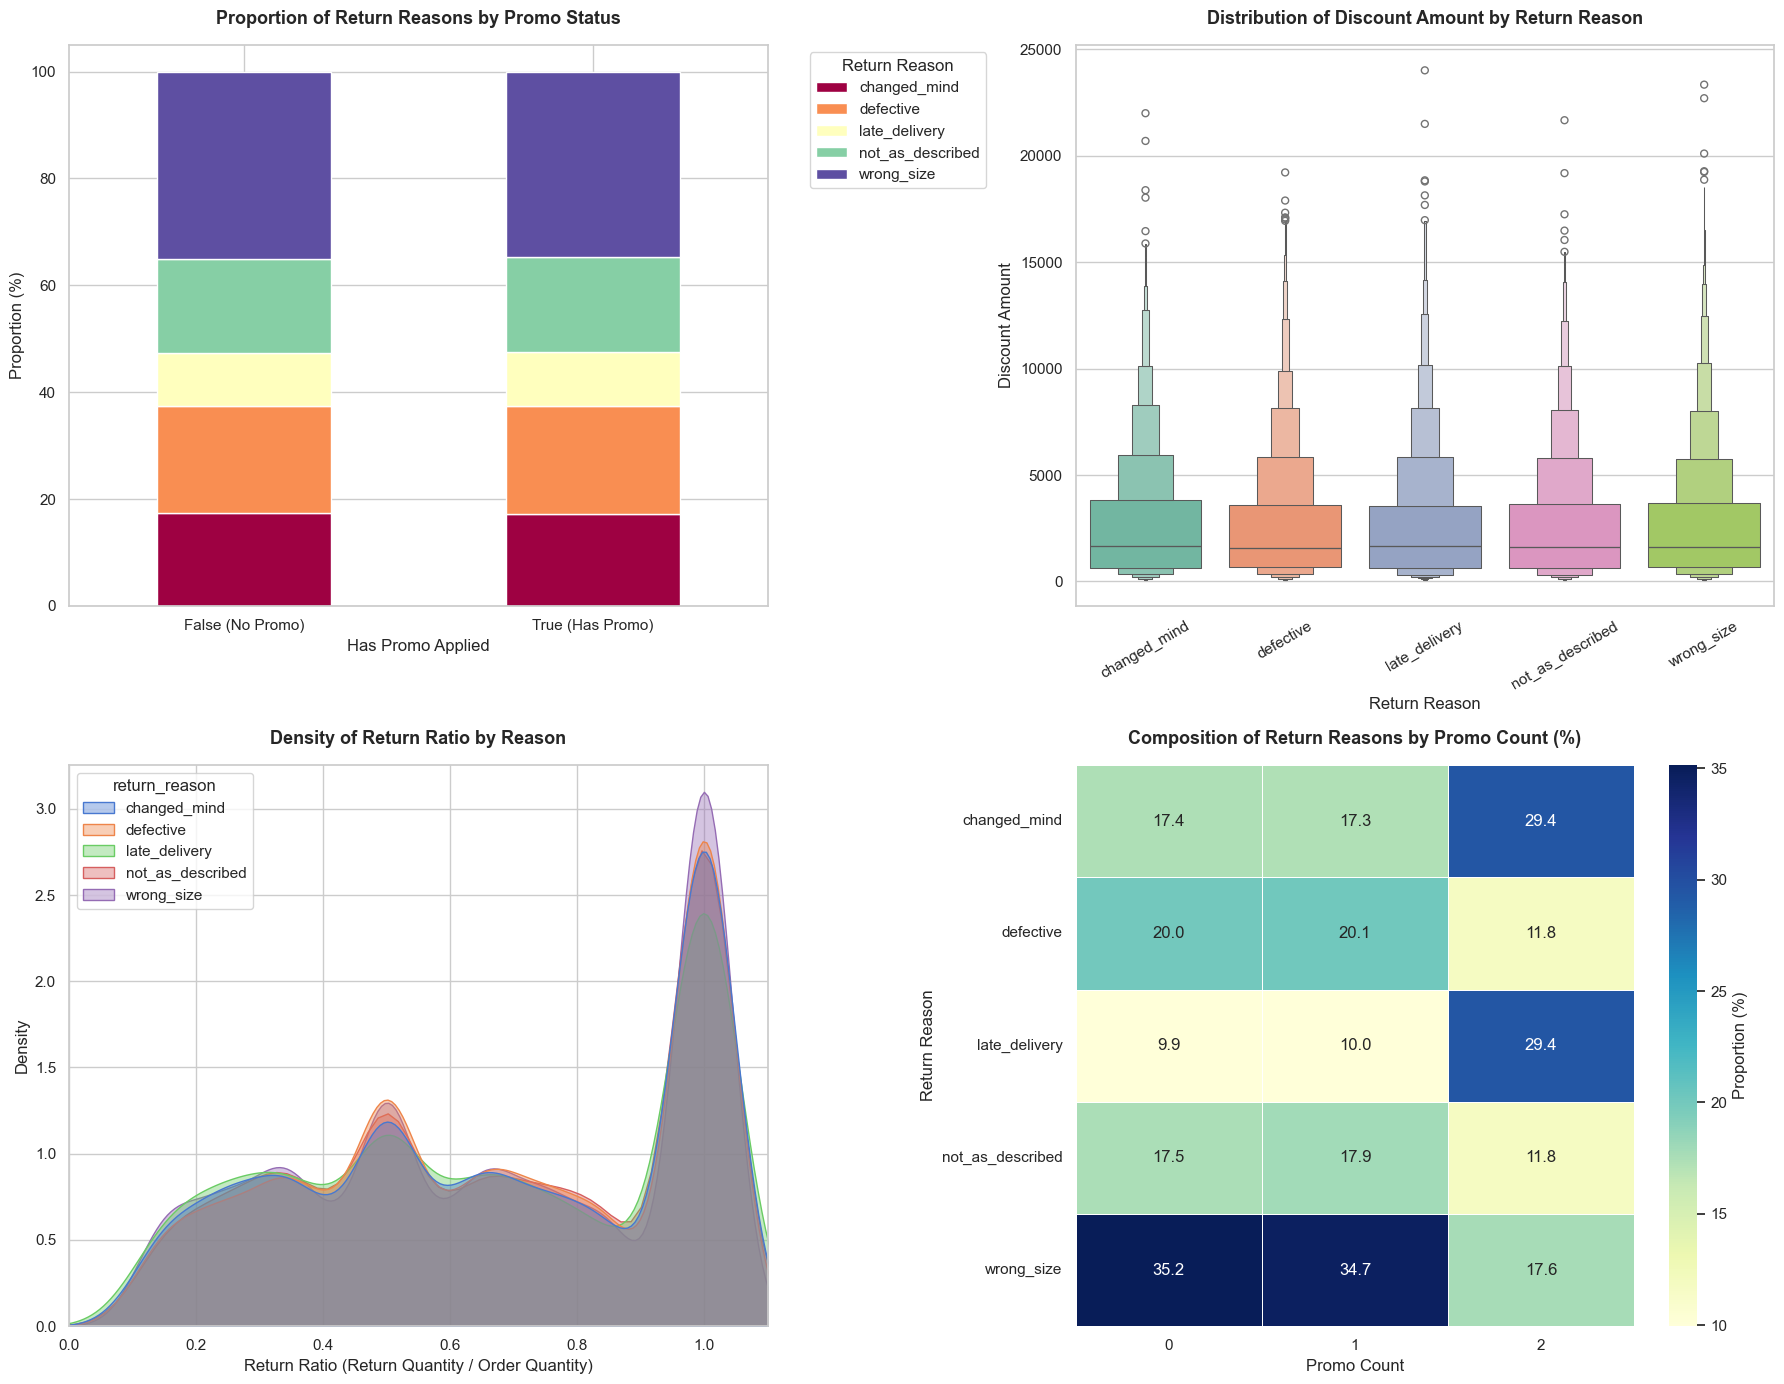

In [9]:
# 1. FEATURE ENGINEERING
df_ret_pmot = df_ret_pmot.copy()
df_ret_pmot['has_promo'] = (df_ret_pmot['promo_id'] != 'None')
df_ret_pmot['promo_count'] = (df_ret_pmot['promo_id'] != 'None').astype(int) + (df_ret_pmot['promo_id_2'] != 'None').astype(int)
df_ret_pmot['return_ratio'] = np.where(df_ret_pmot['quantity'] > 0, df_ret_pmot['return_quantity'] / df_ret_pmot['quantity'], 0)


# 2. DATA VISUALIZATION (GRID 2x2)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Chart 1: 100% Stacked Bar Chart ---
crosstab_promo = pd.crosstab(df_ret_pmot['has_promo'], df_ret_pmot['return_reason'], normalize='index') * 100
crosstab_promo.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='Spectral', edgecolor='white')
axes[0, 0].set_title('Proportion of Return Reasons by Promo Status', fontsize=13, fontweight='bold', pad=15)
axes[0, 0].set_xlabel('Has Promo Applied')
axes[0, 0].set_ylabel('Proportion (%)')
axes[0, 0].set_xticklabels(['False (No Promo)', 'True (Has Promo)'], rotation=0)
axes[0, 0].legend(title='Return Reason', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Chart 2: Boxen Plot ---
df_discount = df_ret_pmot[df_ret_pmot['discount_amount'] > 0]
sns.boxenplot(
    data=df_discount, x='return_reason', y='discount_amount', 
    hue='return_reason', palette='Set2', legend=False, ax=axes[0, 1]
)
axes[0, 1].set_title('Distribution of Discount Amount by Return Reason', fontsize=13, fontweight='bold', pad=15)
axes[0, 1].set_xlabel('Return Reason')
axes[0, 1].set_ylabel('Discount Amount')
axes[0, 1].tick_params(axis='x', rotation=30)

# --- Chart 3: KDE Plot ---
sns.kdeplot(
    data=df_ret_pmot, x='return_ratio', hue='return_reason', 
    fill=True, common_norm=False, palette='muted', alpha=0.4, ax=axes[1, 0]
)
axes[1, 0].set_title('Density of Return Ratio by Reason', fontsize=13, fontweight='bold', pad=15)
axes[1, 0].set_xlabel('Return Ratio (Return Quantity / Order Quantity)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_xlim(0, 1.1) 

# --- Chart 4: Heatmap ---
heatmap_data_norm = pd.crosstab(
    index=df_ret_pmot['return_reason'], 
    columns=df_ret_pmot['promo_count'], 
    normalize='columns' 
) * 100

sns.heatmap(
    heatmap_data_norm, annot=True, fmt=".1f", cmap='YlGnBu', 
    linewidths=.5, cbar_kws={'label': 'Proportion (%)'}, ax=axes[1, 1]
)
axes[1, 1].set_title('Composition of Return Reasons by Promo Count (%)', fontsize=13, fontweight='bold', pad=15)
axes[1, 1].set_xlabel('Promo Count')
axes[1, 1].set_ylabel('Return Reason')
axes[1, 1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

##### Tóm tắt Insight

- **Khuyến mãi không tác động đến hành vi trả hàng (No Correlation):** Biểu đồ Bar Chart và Boxen Plot chứng minh *return reasons* phân bổ y hệt nhau dù khách mua nguyên giá hay có mã giảm giá. Mức *discount amount* cũng không tạo ra sự khác biệt giữa các lý do. Yếu tố khuyến mãi có thể loại khỏi *features* khi build mô hình dự đoán lý do trả hàng.

- **Vấn đề cốt lõi là kích cỡ (Size Issue):** Bất chấp *promo status*, `wrong_size` luôn là nguyên nhân số 1 (ổn định ở mức ~35%). Đây là *bottleneck* lớn nhất cần xử lý ở khâu vận hành/tư vấn.

- **Hành vi hoàn trả toàn phần (All-or-Nothing Return):** Biểu đồ KDE Plot có đỉnh (*peak*) tập trung tuyệt đối tại mốc 1.0 đối với mọi lý do. Khách hàng gần như luôn trả lại toàn bộ *quantity* của sản phẩm đó trong đơn, rất hiếm khi giữ lại một phần (partial return).

- **Hiện tượng nhiễu thống kê ở nhóm 2 mã KM (Statistical Noise):** Heatmap cho thấy tỷ lệ `changed_mind` và `late_delivery` tăng vọt ở nhóm `promo_count = 2`. Tuy nhiên, đối chiếu lại với biểu đồ heatmap số lượng tuyệt đối trước đó, nhóm này có *sample size* vô cùng nhỏ (chỉ vài chục đơn). Sự chênh lệch tỷ lệ này là *noise*, không có giá trị *statistical significance*.


#### return with product

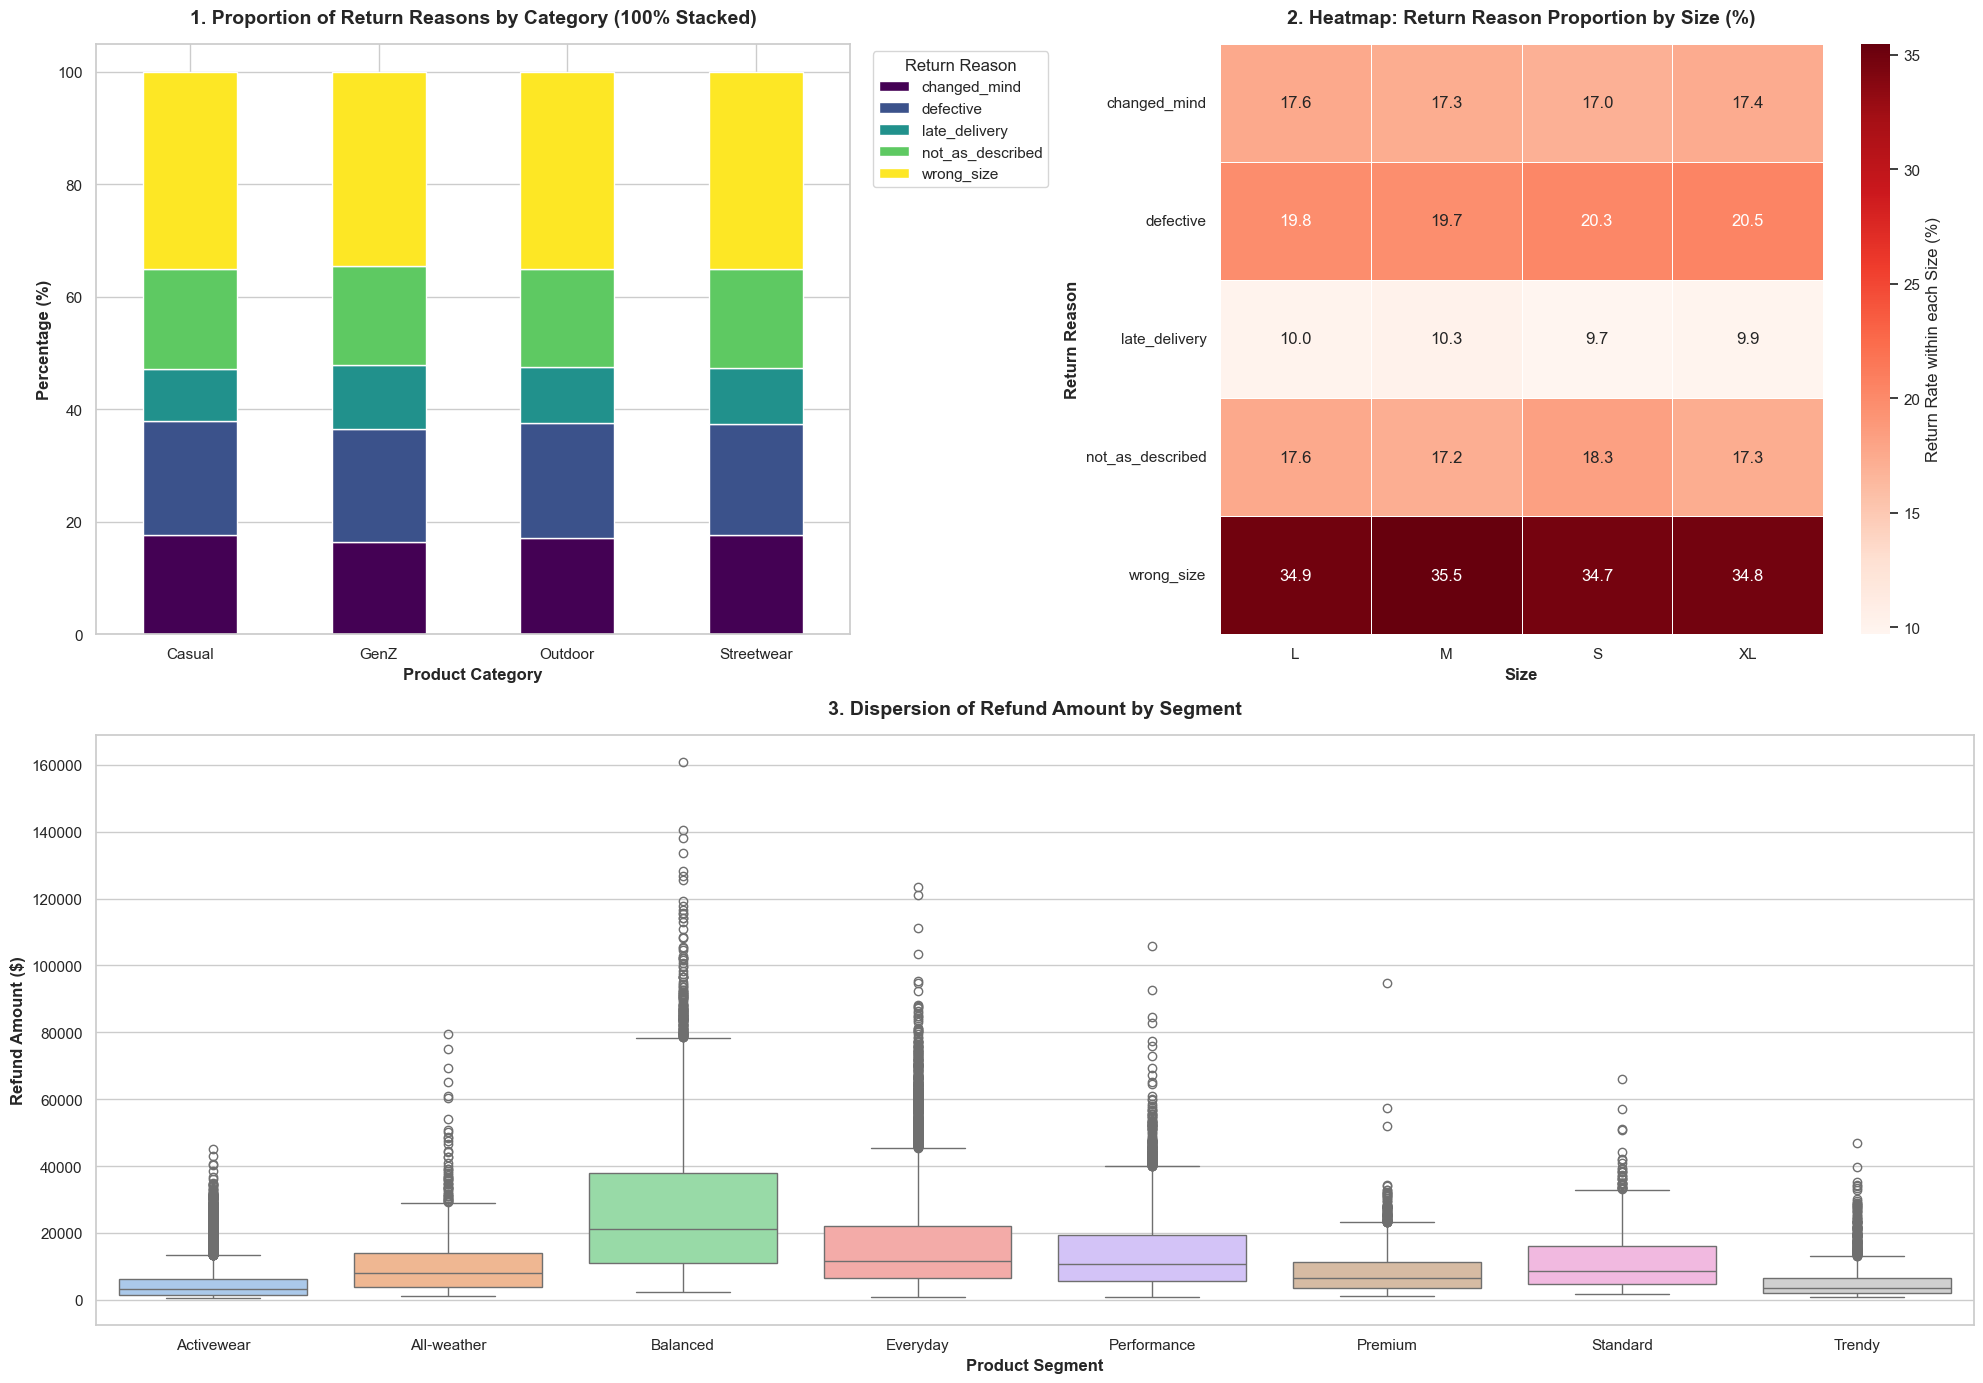

In [10]:
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])


# CHART 1: 100% Stacked Bar Chart (Proportion of return reasons by Category)
ax1 = fig.add_subplot(gs[0, 0])
cross_tab_cat = pd.crosstab(df_ret_pduct['category'], df_ret_pduct['return_reason'], normalize='index') * 100
cross_tab_cat.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis', edgecolor='white')
ax1.set_title('1. Proportion of Return Reasons by Category (100% Stacked)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=0) 
ax1.legend(title='Return Reason', bbox_to_anchor=(1.02, 1), loc='upper left')


# CHART 2: Heatmap (Concentration Level Size vs Return Reason - Percentage %)
ax2 = fig.add_subplot(gs[0, 1])
cross_tab_size_pct = pd.crosstab(df_ret_pduct['return_reason'], df_ret_pduct['size'], normalize='columns') * 100
sns.heatmap(cross_tab_size_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax2,
            cbar_kws={'label': 'Return Rate within each Size (%)'}, linewidths=.5)

ax2.set_title('2. Heatmap: Return Reason Proportion by Size (%)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Size', fontsize=12, fontweight='bold')
ax2.set_ylabel('Return Reason', fontsize=12, fontweight='bold')


# CHART 3: Boxplot (Dispersion of Refund Amount by Segment)
ax3 = fig.add_subplot(gs[1, :])

sns.boxplot(data=df_ret_pduct, x='segment', y='refund_amount', ax=ax3,
            palette='pastel', showfliers=True) 
ax3.set_title('3. Dispersion of Refund Amount by Segment', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Product Segment', fontsize=12, fontweight='bold')
ax3.set_ylabel('Refund Amount ($)', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('bivariate_multivariate_returns_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

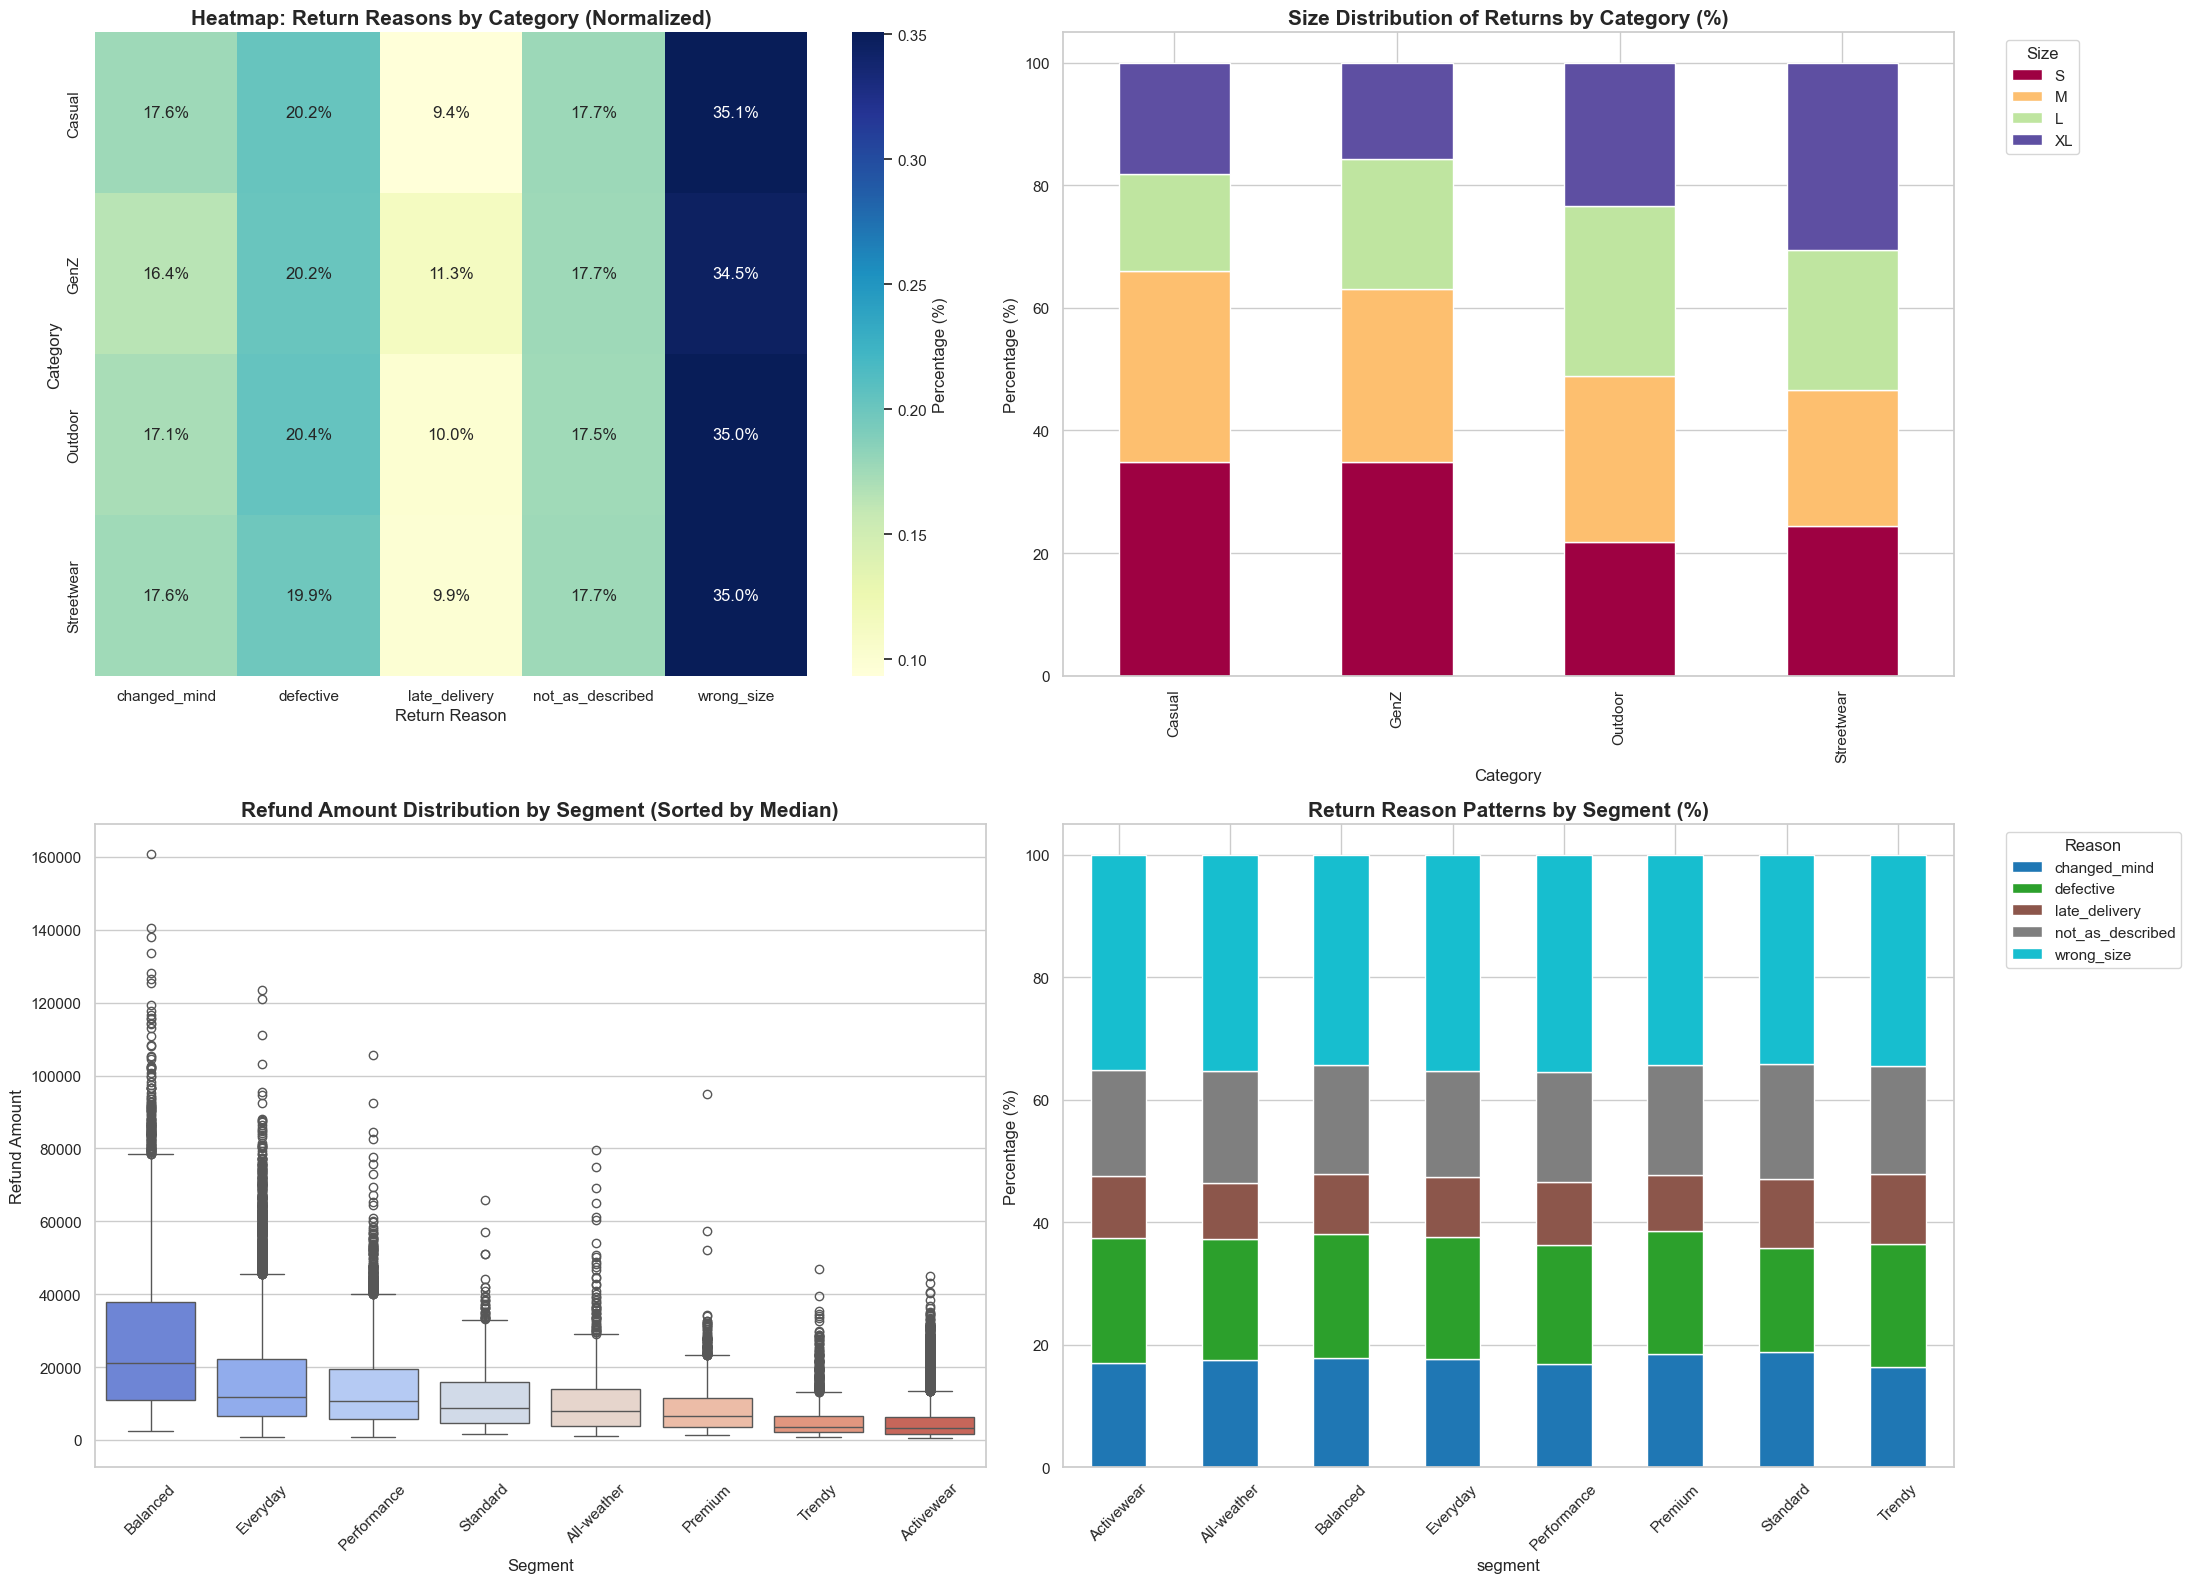

In [11]:

# Create a 2x2 grid for multivariate analysis
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# ---------------------------------------------------------
# 1. Heatmap: Relationship between Product Category and Return Reason
# Insight: Identifying if specific categories have unique return drivers 
# (e.g., Are sizing issues strictly a Streetwear problem?)
# ---------------------------------------------------------
category_reason_pivot = pd.crosstab(df_ret_pduct['category'], df_ret_pduct['return_reason'], normalize='index')
sns.heatmap(category_reason_pivot, annot=True, fmt=".1%", cmap="YlGnBu", ax=axes[0, 0], cbar_kws={'label': 'Percentage (%)'})
axes[0, 0].set_title('Heatmap: Return Reasons by Category (Normalized)', fontsize=15, fontweight='bold')
axes[0, 0].set_xlabel('Return Reason', fontsize=12)
axes[0, 0].set_ylabel('Category', fontsize=12)

# ---------------------------------------------------------
# 2. Stacked Bar Chart: Size Distribution within each Category
# Insight: Checking for size-related anomalies across categories 
# (e.g., XL returns being disproportionately high in specific lines)
# ---------------------------------------------------------
size_order = ['S', 'M', 'L', 'XL']
category_size_dist = df_ret_pduct.groupby(['category', 'size']).size().unstack(fill_value=0)
# Ensure columns are in logical order: S -> M -> L -> XL
category_size_dist = category_size_dist.reindex(columns=size_order)
# Convert to percentage for better comparison across categories with different volumes
category_size_dist_pct = category_size_dist.div(category_size_dist.sum(axis=1), axis=0) * 100

category_size_dist_pct.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Spectral')
axes[0, 1].set_title('Size Distribution of Returns by Category (%)', fontsize=15, fontweight='bold')
axes[0, 1].set_xlabel('Category', fontsize=12)
axes[0, 1].set_ylabel('Percentage (%)', fontsize=12)
axes[0, 1].legend(title='Size', bbox_to_anchor=(1.05, 1), loc='upper left')

# ---------------------------------------------------------
# 3. Boxplot: Refund Amount Distribution by Segment
# Insight: Visualizing financial impact and outliers per segment. 
# Sorted by median to highlight segments with higher refund liabilities.
# ---------------------------------------------------------
segment_order = df_ret_pduct.groupby('segment')['refund_amount'].median().sort_values(ascending=False).index
sns.boxplot(data=df_ret_pduct, x='segment', y='refund_amount', order=segment_order, ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set_title('Refund Amount Distribution by Segment (Sorted by Median)', fontsize=15, fontweight='bold')
axes[1, 0].set_xlabel('Segment', fontsize=12)
axes[1, 0].set_ylabel('Refund Amount', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

# ---------------------------------------------------------
# 4. Grouped Bar Chart: Return Reasons Breakdown by Segment
# Insight: Comparing how product quality (defective) vs. logistics (late_delivery) 
# affects different customer segments differently.
# ---------------------------------------------------------
segment_reason_pct = pd.crosstab(df_ret_pduct['segment'], df_ret_pduct['return_reason'], normalize='index') * 100
segment_reason_pct.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='tab10')
axes[1, 1].set_title('Return Reason Patterns by Segment (%)', fontsize=15, fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Reason', bbox_to_anchor=(1.05, 1))

# Final formatting
plt.tight_layout()
plt.savefig('multivariate_analysis_returns.png', dpi=300, bbox_inches='tight')

##### Tóm tắt Insight

- **Vấn đề hệ thống: Sai lệch kích cỡ (Systemic Size Issue):** Bất chấp danh mục hay phân khúc, `wrong_size` luôn là nguyên nhân số 1 gây trả hàng (ổn định ở mức **~35%**). Đây không phải vấn đề đơn lẻ mà là một *bottleneck* lớn trong bảng quy chuẩn size hoặc quy trình tư vấn kích cỡ của toàn thương hiệu.

- **Sự lệch pha về Form dáng (Sizing Bias):** Nhóm **Casual**/**GenZ** có tỷ lệ trả hàng tập trung cực cao ở Size **S** và **M** (>60%), trong khi **Outdoor**/**Streetwear** lại bị trả chủ yếu ở Size **L** và **XL** (>50%). Insight cho thấy các dòng mặc hàng ngày đang bị form *quá nhỏ*, còn các dòng đồ chất liệu dày/rộng lại đang bị form *quá lớn* so với kỳ vọng.

- **Rủi ro tài chính từ phân khúc Balanced:**  Mặc dù số lượng đơn trả hàng không phải nhiều nhất, nhưng mỗi đơn trả của nhóm này lại có mức hoàn tiền trung vị (median `refund_amount`) cao nhất và biên độ dao động lớn nhất. Đây là phân khúc gây thiệt hại tài chính lớn nhất cho công ty, cần ưu tiên kiểm soát chất lượng (QC) để giảm thiểu tổn thất.

- **Tỷ lệ hàng lỗi ổn định ở mức báo động (Defective Stability):** Lý do **defective** đứng thứ hai sau sai size, duy trì mức **~20%** không đổi trên toàn bộ hệ thống. Việc tỷ lệ này tương đương nhau giữa hàng **Premium** và **Standard** cho thấy quy trình kiểm soát chất lượng (QC) hiện tại đang bị cào bằng, chưa có sự thắt chặt tương xứng cho các dòng hàng cao cấp.

- **Hành vi hoàn trả không phụ thuộc phân khúc (Homogeneous Behavior):** Biểu đồ cơ cấu lý do trả hàng cho thấy sự tương đồng gần như y hệt nhau giữa các nhóm khách hàng. Điều này củng cố giả thuyết rằng các vấn đề nằm ở quy trình vận hành và sản phẩm (nội tại doanh nghiệp) hơn là do đặc tính riêng biệt của từng tệp khách hàng.

#### return with customer

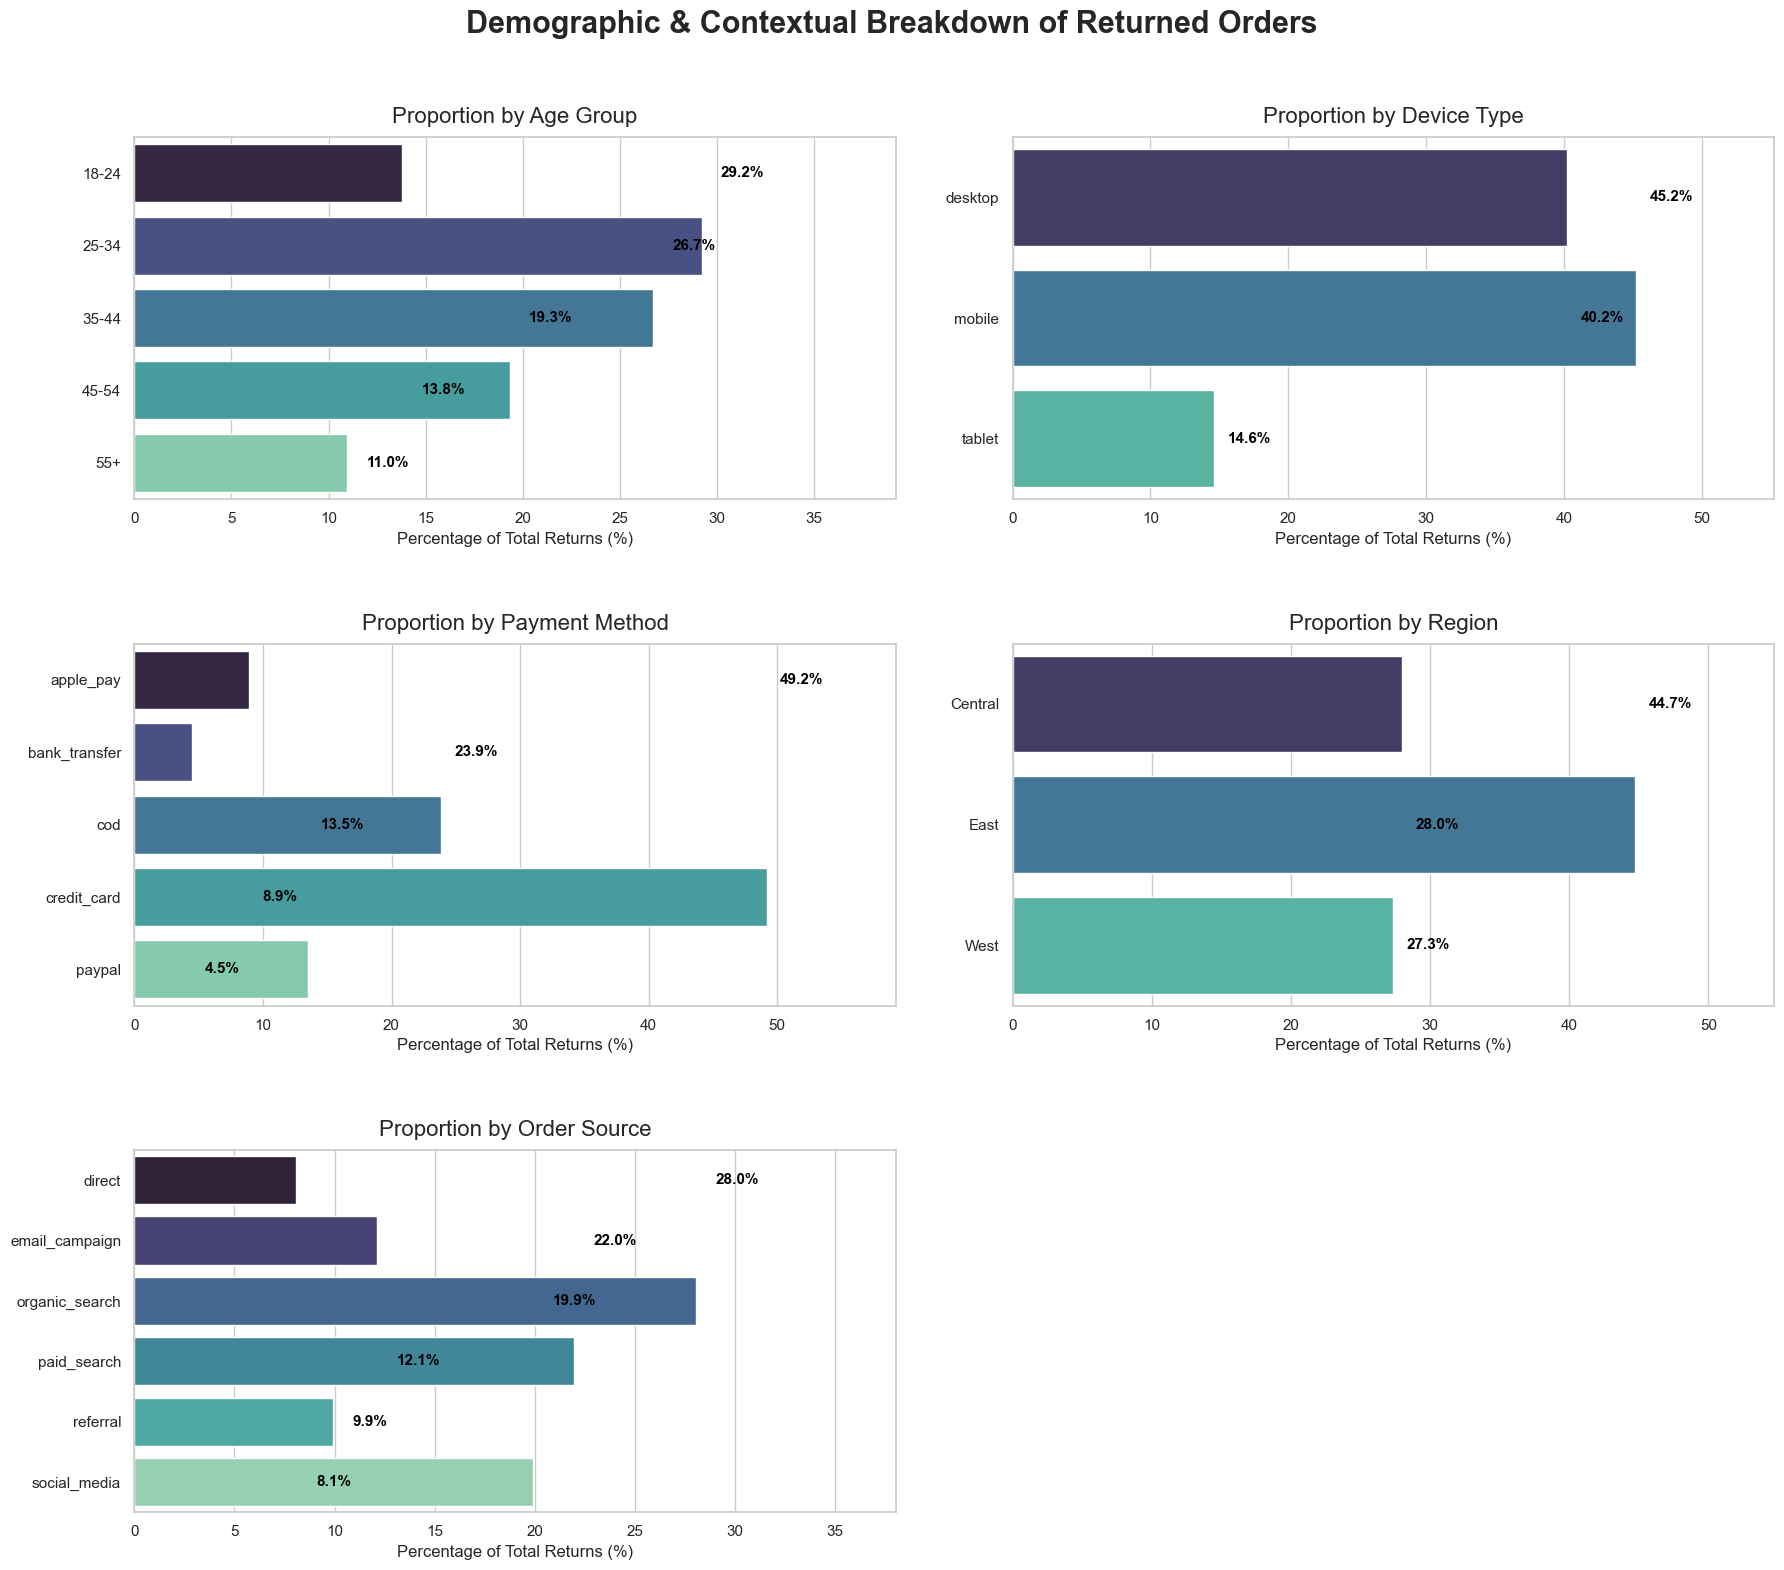

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURATION & SETUP
# ==========================================
# Set seaborn style for clean, modern aesthetics
sns.set_theme(style="whitegrid")

# Define the columns we want to analyze
cols_to_plot = ['age_group', 'device_type', 'payment_method', 'region', 'order_source']

# Create a figure and a 3x2 grid of subplots (6 slots total, we will use 5)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 16))
fig.suptitle('Demographic & Contextual Breakdown of Returned Orders', 
             fontsize=22, fontweight='bold', y=0.98)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# ==========================================
# ITERATE AND PLOT PERCENTAGES
# ==========================================
for i, col in enumerate(cols_to_plot):
    
    # 1. Calculate percentage distribution for the column
    # value_counts(normalize=True) gives fractions, multiply by 100 for percentages
    dist_df = df_ret_ord_cus[col].value_counts(normalize=True).reset_index()
    dist_df.columns = [col, 'percentage']
    dist_df['percentage'] = dist_df['percentage'] * 100
    
    # Sort values descending for better visual flow in horizontal bar charts
    dist_df = dist_df.sort_values(by='percentage', ascending=False)
    
    # 2. Plot horizontal bar chart
    # Using 'mako' palette for a professional look
    sns.barplot(data=dist_df, x='percentage', y=col, ax=axes[i], palette='mako')
    
    # 3. Add data labels (percentage text) to the end of each bar
    for index, row in dist_df.iterrows():
        # Place text slightly to the right of the bar's end (row['percentage'] + 1)
        axes[i].text(x=row['percentage'] + 1, 
                     y=index, 
                     s=f"{row['percentage']:.1f}%", 
                     va='center', 
                     fontsize=11, 
                     color='black',
                     fontweight='semibold')
        
    # 4. Formatting the axes
    axes[i].set_title(f'Proportion by {col.replace("_", " ").title()}', fontsize=16, pad=10)
    axes[i].set_xlabel('Percentage of Total Returns (%)', fontsize=12)
    axes[i].set_ylabel('') # Remove y-axis label to keep it clean
    
    # Extend x-axis slightly so the text labels don't get cut off
    max_val = dist_df['percentage'].max()
    axes[i].set_xlim(0, max_val + 10) 

# ==========================================
# FINAL CLEANUP
# ==========================================
# We have 5 charts but a 3x2 grid (6 slots). Hide the 6th empty subplot.
axes[5].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=4.0, w_pad=3.0)
plt.show()

#### return with shipment

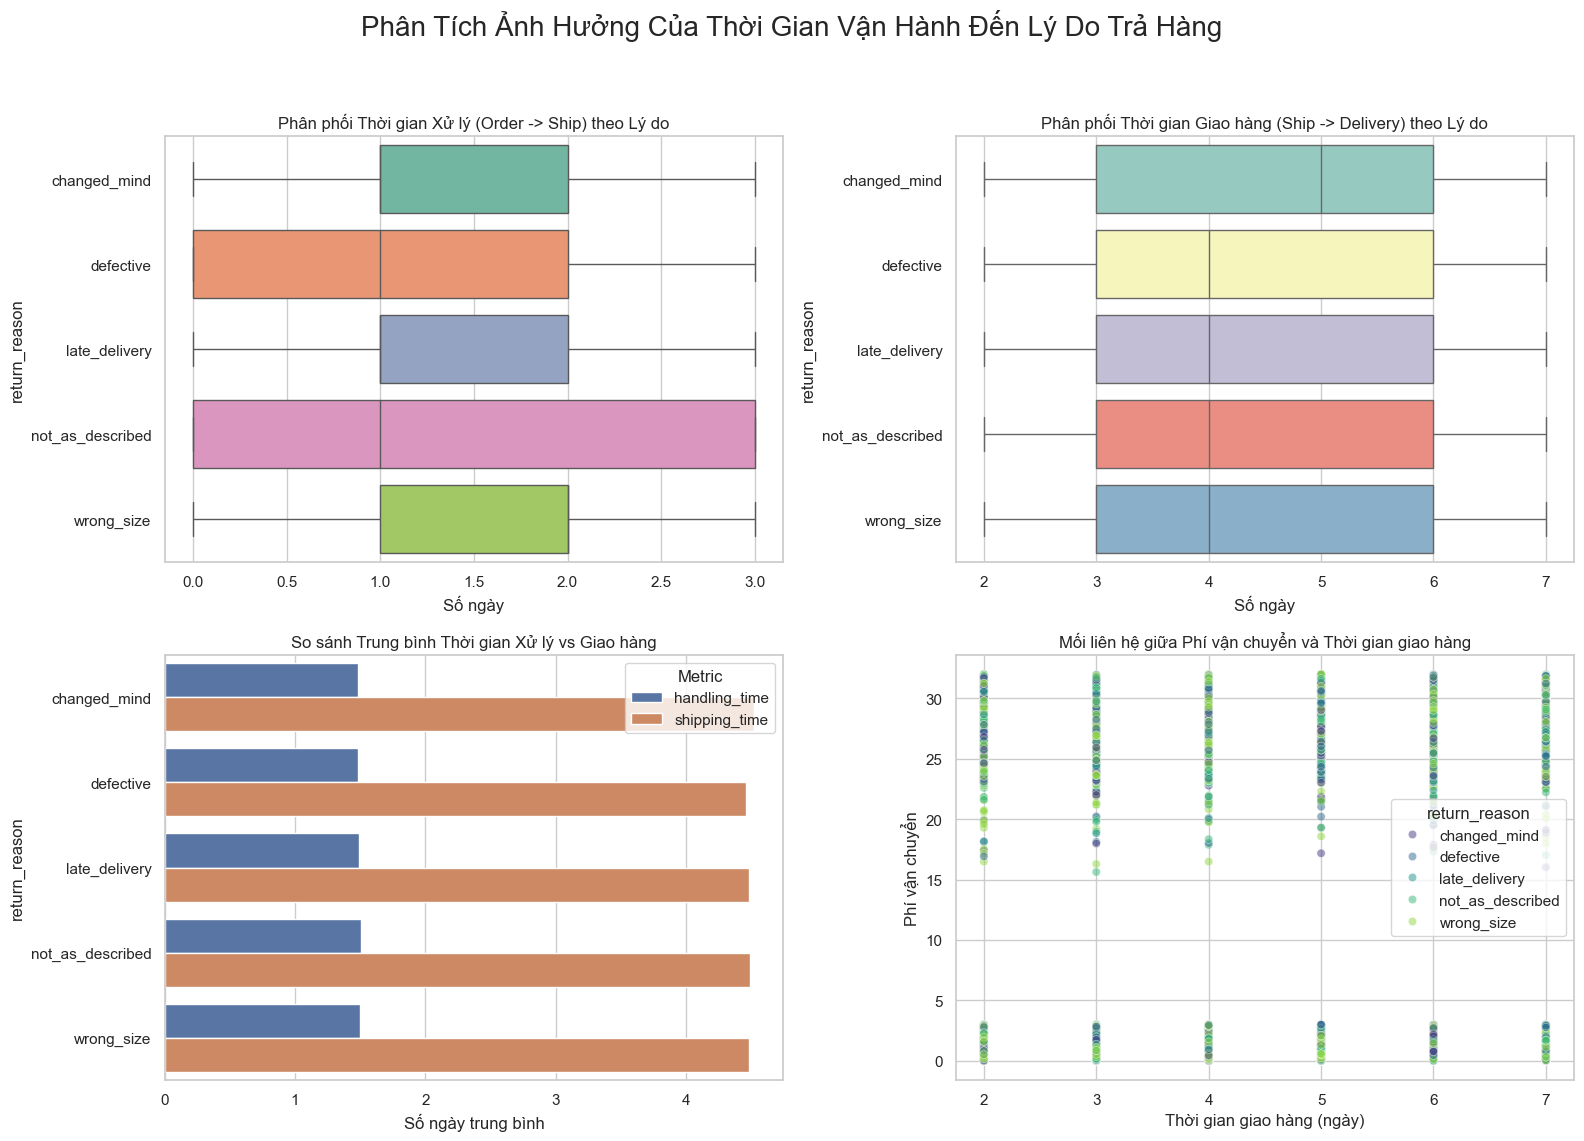

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tiền xử lý: Tính toán các khoảng thời gian (đơn vị: ngày)
df_ret_ship['handling_time'] = (df_ret_ship['ship_date'] - df_ret_ship['order_date']).dt.days
df_ret_ship['shipping_time'] = (df_ret_ship['delivery_date'] - df_ret_ship['ship_date']).dt.days

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân Tích Ảnh Hưởng Của Thời Gian Vận Hành Đến Lý Do Trả Hàng', fontsize=20)

# --- Biểu đồ 1: Phân phối Thời gian xử lý theo Lý do (Boxplot) ---
sns.boxplot(ax=axes[0, 0], x='handling_time', y='return_reason', data=df_ret_ship, palette='Set2')
axes[0, 0].set_title('Phân phối Thời gian Xử lý (Order -> Ship) theo Lý do')
axes[0, 0].set_xlabel('Số ngày')

# --- Biểu đồ 2: Phân phối Thời gian giao hàng theo Lý do (Boxplot) ---
sns.boxplot(ax=axes[0, 1], x='shipping_time', y='return_reason', data=df_ret_ship, palette='Set3')
axes[0, 1].set_title('Phân phối Thời gian Giao hàng (Ship -> Delivery) theo Lý do')
axes[0, 1].set_xlabel('Số ngày')

# --- Biểu đồ 3: Trung bình thời gian vận hành theo từng lý do (Barplot) ---
# Gom nhóm dữ liệu để tính trung bình
df_melted = df_ret_ship.groupby('return_reason')[['handling_time', 'shipping_time']].mean().reset_index()
df_melted = df_melted.melt(id_vars='return_reason', var_name='Metric', value_name='Average Days')

sns.barplot(ax=axes[1, 0], x='Average Days', y='return_reason', hue='Metric', data=df_melted)
axes[1, 0].set_title('So sánh Trung bình Thời gian Xử lý vs Giao hàng')
axes[1, 0].set_xlabel('Số ngày trung bình')

# --- Biểu đồ 4: Mối tương quan giữa phí vận chuyển và thời gian giao hàng (Scatter plot) ---
# Giúp kiểm tra xem phí cao hơn có giúp giao hàng nhanh hơn và giảm lý do "late_delivery" không
sns.scatterplot(ax=axes[1, 1], x='shipping_time', y='shipping_fee', hue='return_reason', 
                data=df_ret_ship, alpha=0.5, palette='viridis')
axes[1, 1].set_title('Mối liên hệ giữa Phí vận chuyển và Thời gian giao hàng')
axes[1, 1].set_xlabel('Thời gian giao hàng (ngày)')
axes[1, 1].set_ylabel('Phí vận chuyển')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 📊 TÓM TẮT INSIGHT: ẢNH HƯỞNG CỦA THỜI GIAN VẬN HÀNH ĐẾN LÝ DO TRẢ HÀNG

**1. Điểm nghẽn nằm ở khâu vận chuyển, không phải khâu xử lý tại kho**
* Thời gian giao hàng trung bình (~4.5 ngày) chiếm tỷ trọng gấp 3 lần thời gian xử lý đơn hàng (~1.5 ngày). 
* Giải pháp: Để rút ngắn tổng thời gian đến tay khách hàng, doanh nghiệp cần tập trung tối ưu SLA với các đối tác vận chuyển (Logistics/3PL) thay vì dồn áp lực lên khâu kho bãi.

**2. Nghịch lý của lý do "Giao hàng trễ" (Late Delivery)**
* Khách hàng chọn lý do trả hàng "late_delivery" có thời gian chờ trung vị (~4 ngày) – hoàn toàn tương đương với các nhóm lý do khác như hàng lỗi hay sai kích cỡ.
* Giải pháp: Sự phàn nàn này có thể xuất phát từ việc **thời gian giao hàng thực tế vượt quá cam kết hiển thị ban đầu**. Cần kiểm tra lại hệ thống ước tính thời gian giao hàng (ETA) trên nền tảng để quản lý đúng kỳ vọng của khách hàng.

**3. Phí vận chuyển cao không đảm bảo tốc độ giao hàng nhanh**
* Không có sự tương quan tuyến tính giữa việc trả phí vận chuyển cao (mức 15-32) và thời gian nhận hàng. 
* Nhiều đơn hàng chịu phí vận chuyển cao vẫn mất từ 6-7 ngày để đến tay khách hàng. Sự bất cập này có thể làm tăng sự bực bội, khiến khách hàng dễ "đổi ý" (changed_mind) hoặc khắt khe hơn với sản phẩm.

> **💡 KẾT LUẬN CHUNG:**
> Thời gian vận hành thực tế **không tạo ra sự phân hóa** giữa các lý do trả hàng (mọi nhóm lý do đều có phổ thời gian trải nghiệm tương tự nhau). Tuy nhiên, dữ liệu đã bộc lộ những lỗ hổng trong việc quản lý kỳ vọng khách hàng (cam kết thời gian chưa chuẩn xác) và sự thiếu hiệu quả của các gói vận chuyển có thu phí cao.

## model

In [14]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

# Đảm bảo tính tái lập (Reproducibility) theo yêu cầu BTC
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. LOAD DATA
# Giả sử bạn đã có file sales.csv trong cùng thư mục
df_sales = df_sale.copy()
df_sales = df_sales.sort_values('Date').reset_index(drop=True)

# 2. FEATURE ENGINEERING
def create_features(df):
    """
    Hàm tạo đặc trưng từ cột Date. 
    Lưu ý: Chỉ dùng những thông tin có thể biết trước trong tương lai!
    """
    df = df.copy()
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter'] = df['Date'].dt.quarter
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['dayofmonth'] = df['Date'].dt.day
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    
    # Feature Mùa vụ / Cuối tuần
    df['is_weekend'] = np.where(df['dayofweek'].isin([5, 6]), 1, 0)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
    
    # Bạn có thể thêm Feature: Lễ tết, Black Friday, v.v.
    # Ví dụ mô phỏng: tháng 11, 12 thường là mùa mua sắm
    df['is_shopping_season'] = np.where(df['month'].isin([11, 12]), 1, 0)
    
    return df

df_features = create_features(df_sales)

# Phân tách tập features (X) và target (y)
FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 
            'dayofmonth', 'weekofyear', 'is_weekend', 'is_month_start', 
            'is_month_end', 'is_shopping_season']
TARGET_REV = 'Revenue'
TARGET_COGS = 'COGS'

ModuleNotFoundError: No module named 'shap'

In [ ]:
# 3. SPLIT DATA: Train (2012 - 2021) và Validation (2022)
train_mask = (df_features['Date'] >= '2012-07-04') & (df_features['Date'] <= '2021-12-31')
val_mask = (df_features['Date'] >= '2022-01-01') & (df_features['Date'] <= '2022-12-31')

train = df_features.loc[train_mask]
val = df_features.loc[val_mask]

X_train = train[FEATURES]
y_train_rev = train[TARGET_REV]
y_train_cogs = train[TARGET_COGS]

X_val = val[FEATURES]
y_val_rev = val[TARGET_REV]
y_val_cogs = val[TARGET_COGS]

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}")

Train size: (3468, 11), Validation size: (365, 11)


In [ ]:
# 4. TRAINING & EVALUATION
def train_and_evaluate(X_tr, y_tr, X_v, y_v, target_name):
    print(f"--- Training Model for {target_name} ---")
    
    # Khởi tạo mô hình XGBoost
    model = xgb.XGBRegressor(
        n_estimators=1000, 
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        early_stopping_rounds=50
    )
    
    # Fit mô hình
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_v, y_v)],
        verbose=100
    )
    
    # Dự đoán trên tập Validation
    preds = model.predict(X_v)
    
    # Tính toán các Metrics theo yêu cầu BTC
    mae = mean_absolute_error(y_v, preds)
    rmse = np.sqrt(mean_squared_error(y_v, preds))
    r2 = r2_score(y_v, preds)
    
    print(f"Results for {target_name}:")
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.4f}\n")
    
    return model, preds

# Train mô hình cho Revenue
model_rev, preds_rev = train_and_evaluate(X_train, y_train_rev, X_val, y_val_rev, "Revenue")

# Train mô hình cho COGS
model_cogs, preds_cogs = train_and_evaluate(X_train, y_train_cogs, X_val, y_val_cogs, "COGS")

--- Training Model for Revenue ---
[0]	validation_0-rmse:2597207.11817	validation_1-rmse:1977769.24646
[99]	validation_0-rmse:811969.25285	validation_1-rmse:850296.96762
Results for Revenue:
MAE: 595302.86 | RMSE: 821840.77 | R²: 0.7589

--- Training Model for COGS ---
[0]	validation_0-rmse:2194599.46817	validation_1-rmse:1700220.73129
[100]	validation_0-rmse:650658.93685	validation_1-rmse:708421.81346
[109]	validation_0-rmse:630951.47575	validation_1-rmse:709676.33727
Results for COGS:
MAE: 524300.95 | RMSE: 706288.77 | R²: 0.7655



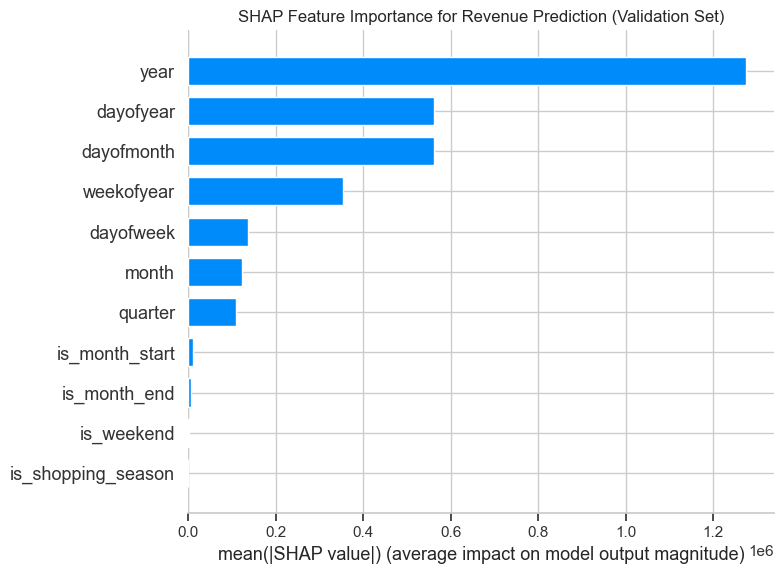

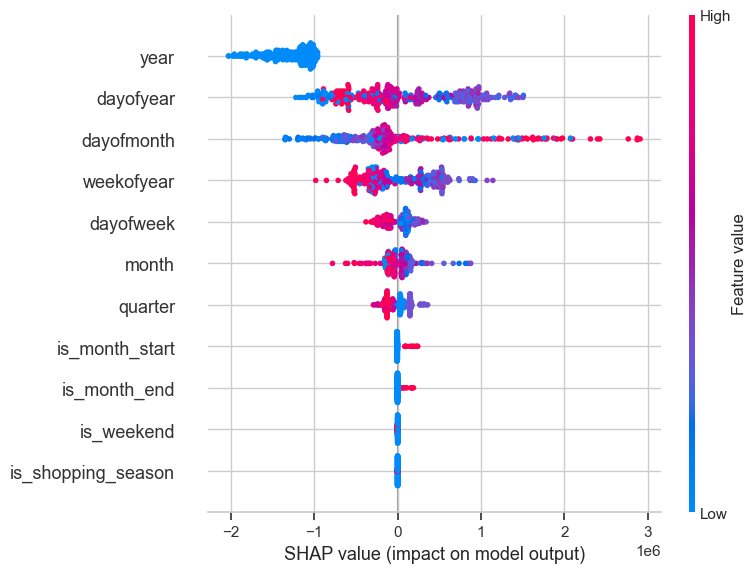

In [ ]:
# 5. MODEL EXPLAINABILITY (SHAP)
# Tính toán SHAP values cho mô hình Revenue
explainer = shap.TreeExplainer(model_rev)
shap_values = explainer.shap_values(X_val)

# Vẽ biểu đồ mức độ quan trọng của các Features (Feature Importance)
plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance for Revenue Prediction (Validation Set)")
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Vẽ biểu đồ mật độ (Summary plot) để xem tác động cụ thể
# Ví dụ: Tháng 11, 12 (is_shopping_season = 1) làm tăng hay giảm doanh thu?
shap.summary_plot(shap_values, X_val)

## Cũ

In [ ]:
print(len(df_ship[df_ship['order_id'].duplicated(keep=False)]))
print(len(df_ret[df_ret['order_id'].duplicated(keep=False)]))
print(len(df_rev[df_rev['order_id'].duplicated(keep=False)]))

0
7678
4361


In [ ]:
df_ret = df_ret.merge(df_pduct, on='product_id', how='left')
df_rev = df_rev.merge(df_pduct, on='product_id', how='left')
df_ret.info()
df_rev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   return_id        39939 non-null  string        
 1   order_id         39939 non-null  string        
 2   product_id       39939 non-null  string        
 3   return_date      39939 non-null  datetime64[ns]
 4   return_reason    39939 non-null  category      
 5   return_quantity  39939 non-null  int64         
 6   refund_amount    39939 non-null  float64       
 7   date_only        39939 non-null  object        
 8   product_name     39939 non-null  string        
 9   category         39939 non-null  category      
 10  segment          39939 non-null  category      
 11  size             39939 non-null  category      
 12  color            39939 non-null  category      
 13  price            39939 non-null  float64       
 14  cogs             39939 non-null  float

### bảng return

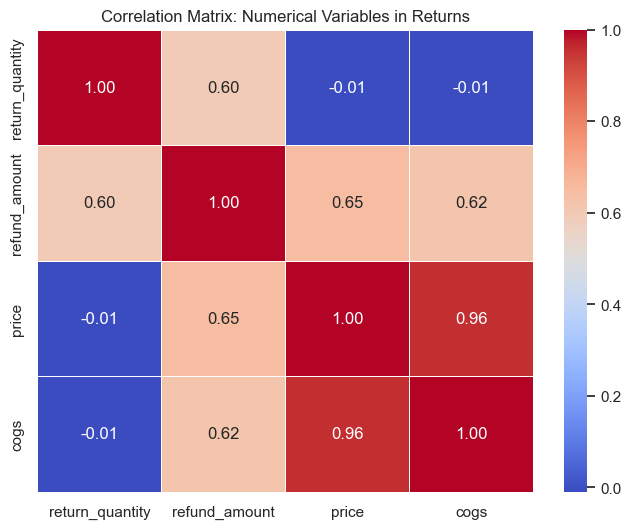

In [ ]:
num_cols_ret = ['return_quantity', 'refund_amount', 'price', 'cogs']
corr_ret = df_ret[num_cols_ret].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_ret, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Numerical Variables in Returns")
plt.show()

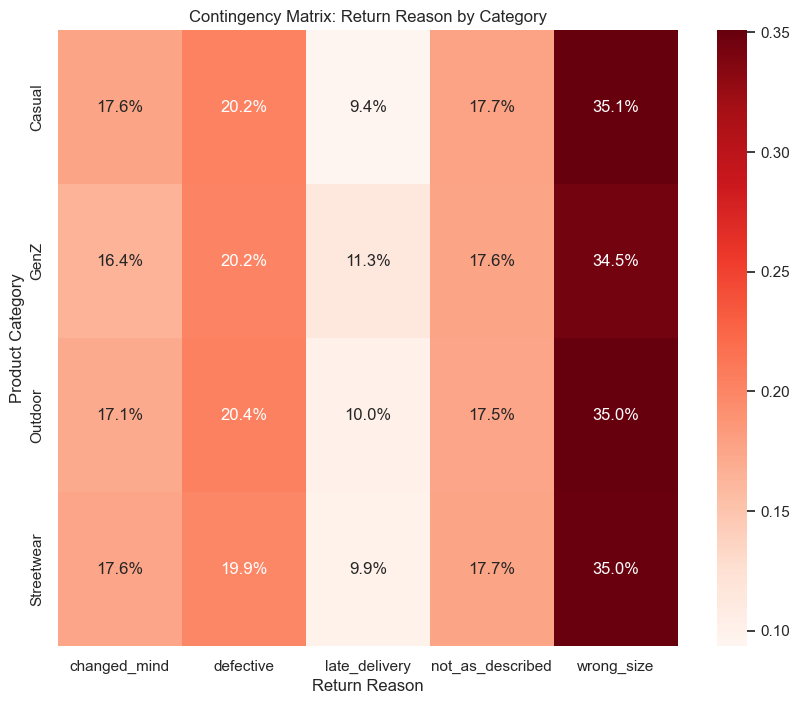

In [ ]:
cross_ret = pd.crosstab(df_ret['category'], df_ret['return_reason'], normalize='index')

plt.figure(figsize=(10, 8))
sns.heatmap(cross_ret, annot=True, cmap='Reds', fmt=".1%")
plt.title("Contingency Matrix: Return Reason by Category")
plt.ylabel("Product Category")
plt.xlabel("Return Reason")
plt.show()

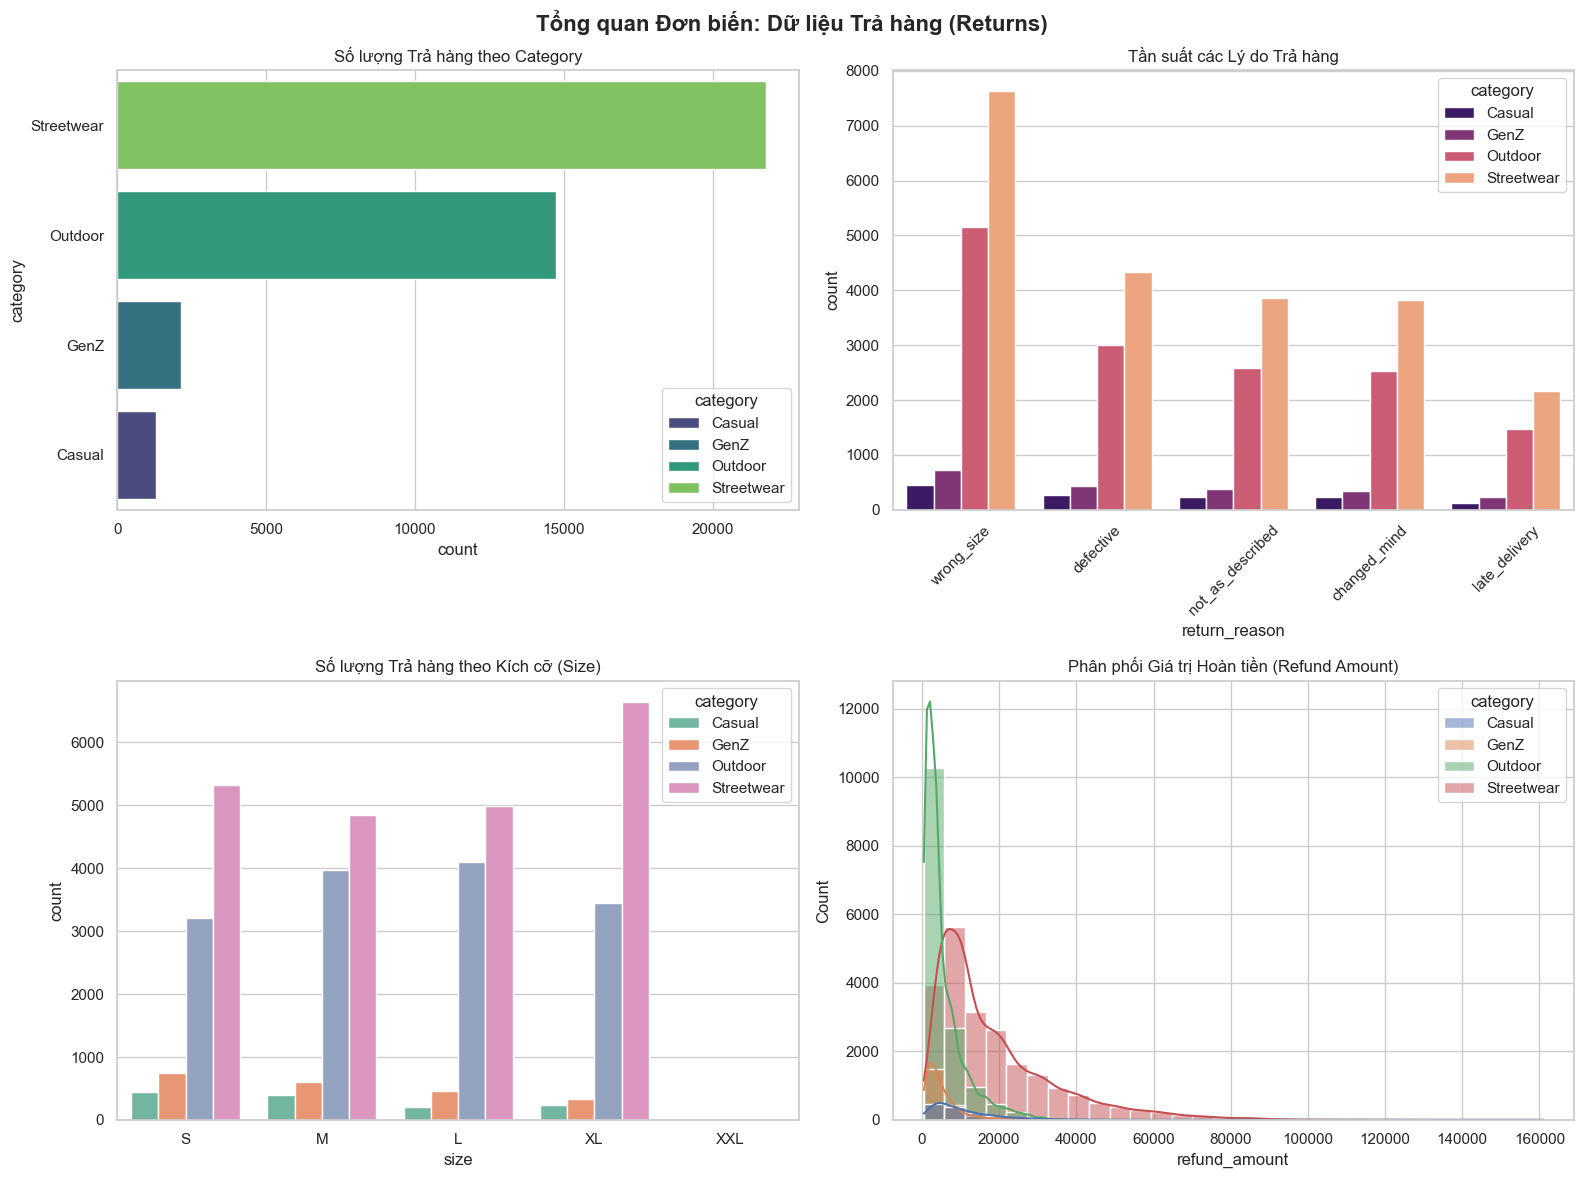

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tổng quan Đơn biến: Dữ liệu Trả hàng (Returns)', fontsize=16, fontweight='bold')

# 1. Phân phối số lượng hoàn trả theo Category
sns.countplot(data=df_ret, y='category', hue='category', legend=True, ax=axes[0, 0], palette='viridis', order=df_ret['category'].value_counts().index)
axes[0, 0].set_title('Số lượng Trả hàng theo Category')

# 2. Phân phối Lý do trả hàng (Return Reason)
sns.countplot(data=df_ret, x='return_reason', hue='category', legend=True, ax=axes[0, 1], palette='magma', order=df_ret['return_reason'].value_counts().index)
axes[0, 1].set_title('Tần suất các Lý do Trả hàng')
axes[0, 1].tick_params(axis='x', rotation=45) # Xoay nhãn trục x cho dễ đọc

# 3. Phân phối kích cỡ (Size) bị trả lại
sns.countplot(data=df_ret, x='size', hue='category', legend=True, ax=axes[1, 0], palette='Set2', order=['S', 'M', 'L', 'XL', 'XXL'])
axes[1, 0].set_title('Số lượng Trả hàng theo Kích cỡ (Size)')

# 4. Phân phối giá trị hoàn tiền (Refund Amount)
sns.histplot(data=df_ret, x='refund_amount', hue='category', legend=True, bins=30, kde=True, ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Phân phối Giá trị Hoàn tiền (Refund Amount)')

plt.tight_layout()
plt.show()

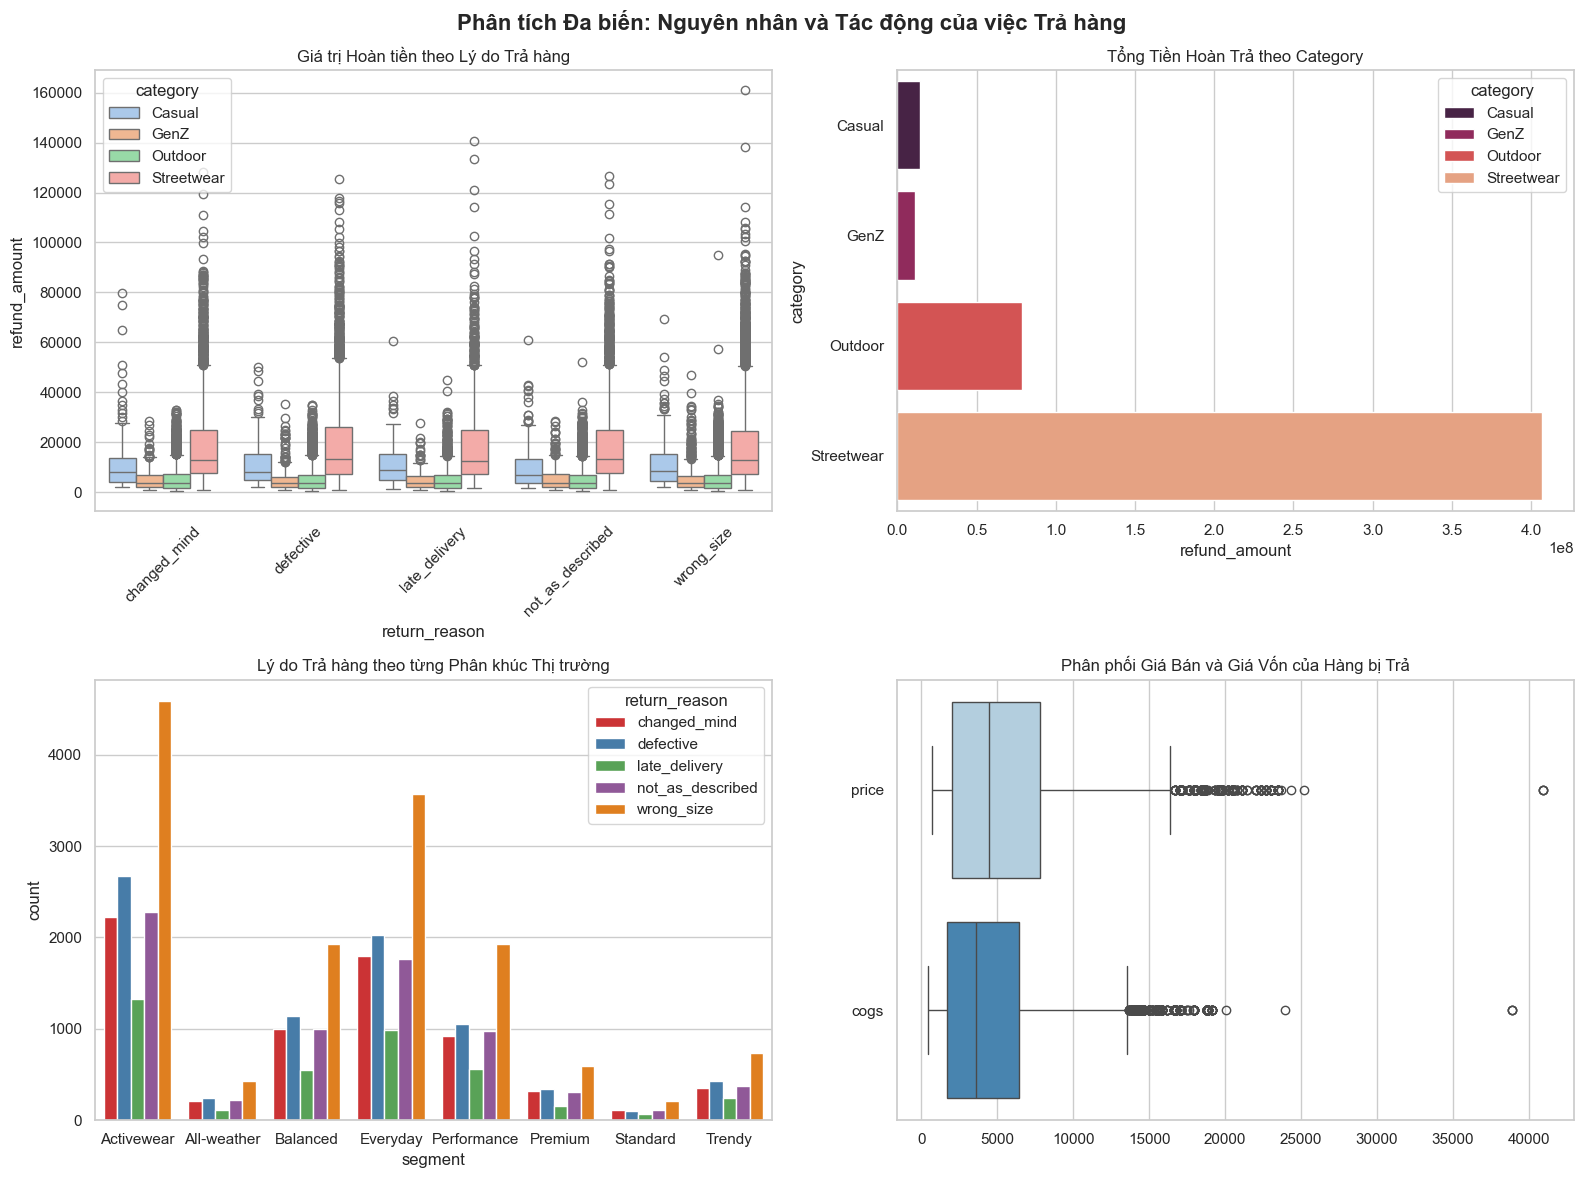

In [ ]:
# Tạo lưới 2x2 cho Returns - Đa biến
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Đa biến: Nguyên nhân và Tác động của việc Trả hàng', fontsize=16, fontweight='bold')

# 1. Boxplot: Lý do trả hàng ảnh hưởng thế nào đến Giá trị hoàn tiền?
sns.boxplot(data=df_ret, x='return_reason', y='refund_amount', hue='category', legend=True, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Giá trị Hoàn tiền theo Lý do Trả hàng')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Barplot: Tổng giá trị hoàn tiền theo Category (Category nào làm "đọng vốn" nhiều nhất?)
# Dùng estimator=sum để tính tổng thay vì trung bình
import numpy as np
sns.barplot(data=df_ret, y='category', x='refund_amount', hue='category', legend=True, estimator=np.sum, ax=axes[0, 1], palette='rocket', errorbar=None)
axes[0, 1].set_title('Tổng Tiền Hoàn Trả theo Category')

# 3. Countplot gom nhóm: Lý do trả hàng theo từng Phân khúc (Segment)
sns.countplot(data=df_ret, x='segment', hue='return_reason', legend=True, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Lý do Trả hàng theo từng Phân khúc Thị trường')

# 4. Boxplot: Sự chênh lệch giữa Giá bán (price) và Giá vốn (cogs) đối với hàng bị trả
sns.boxplot(data=df_ret[['price', 'cogs']], ax=axes[1, 1], orient='h', palette='Blues')
axes[1, 1].set_title('Phân phối Giá Bán và Giá Vốn của Hàng bị Trả')

plt.tight_layout()
plt.show()

### bảng review

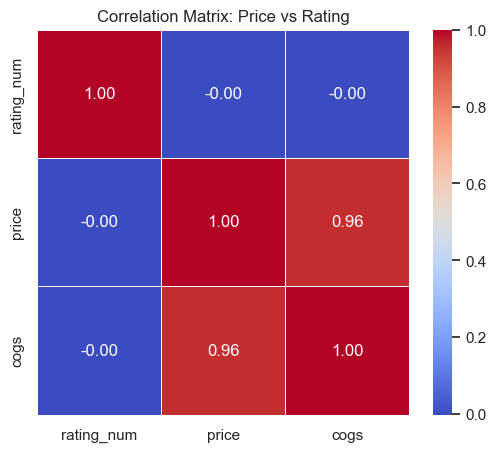

In [ ]:
# Ép kiểu rating về numeric trước khi tính toán
# Lấy ra các chữ số (\d+) đầu tiên xuất hiện trong chuỗi
df_rev['rating_num'] = df_rev['rating'].astype(str).str.extract(r'(\d+)').astype(float)
# df_rev['rating_num'] = df_rev['rating'].astype(float)

num_cols_rev = ['rating_num', 'price', 'cogs']
corr_rev = df_rev[num_cols_rev].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_rev, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Price vs Rating")
plt.show()

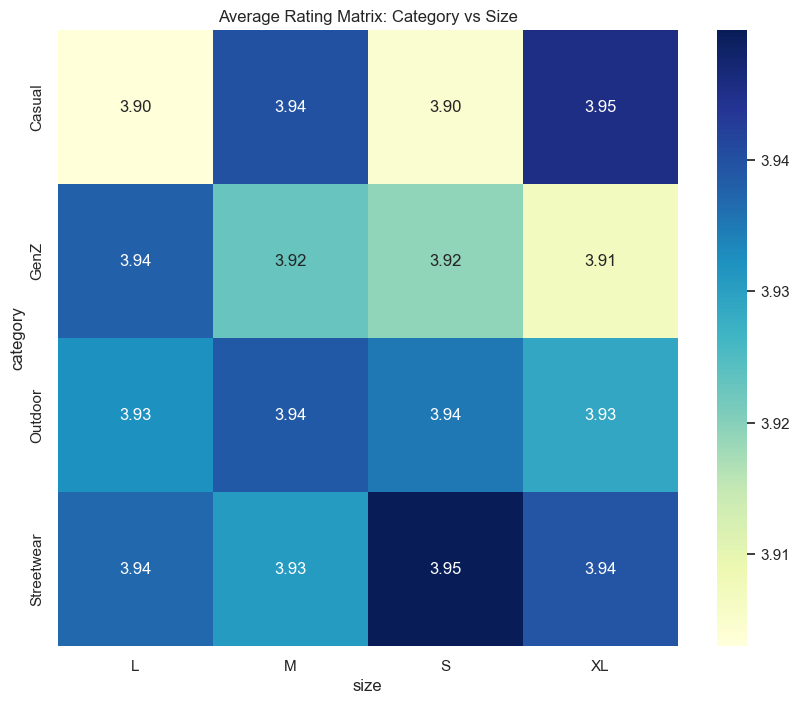

In [ ]:
pivot_rev = pd.pivot_table(
    data=df_rev,
    values='rating_num',
    index='category',
    columns='size',
    aggfunc='mean',
    observed=True  # <--- Thêm dòng này vào đây
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_rev, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Average Rating Matrix: Category vs Size")
plt.show()

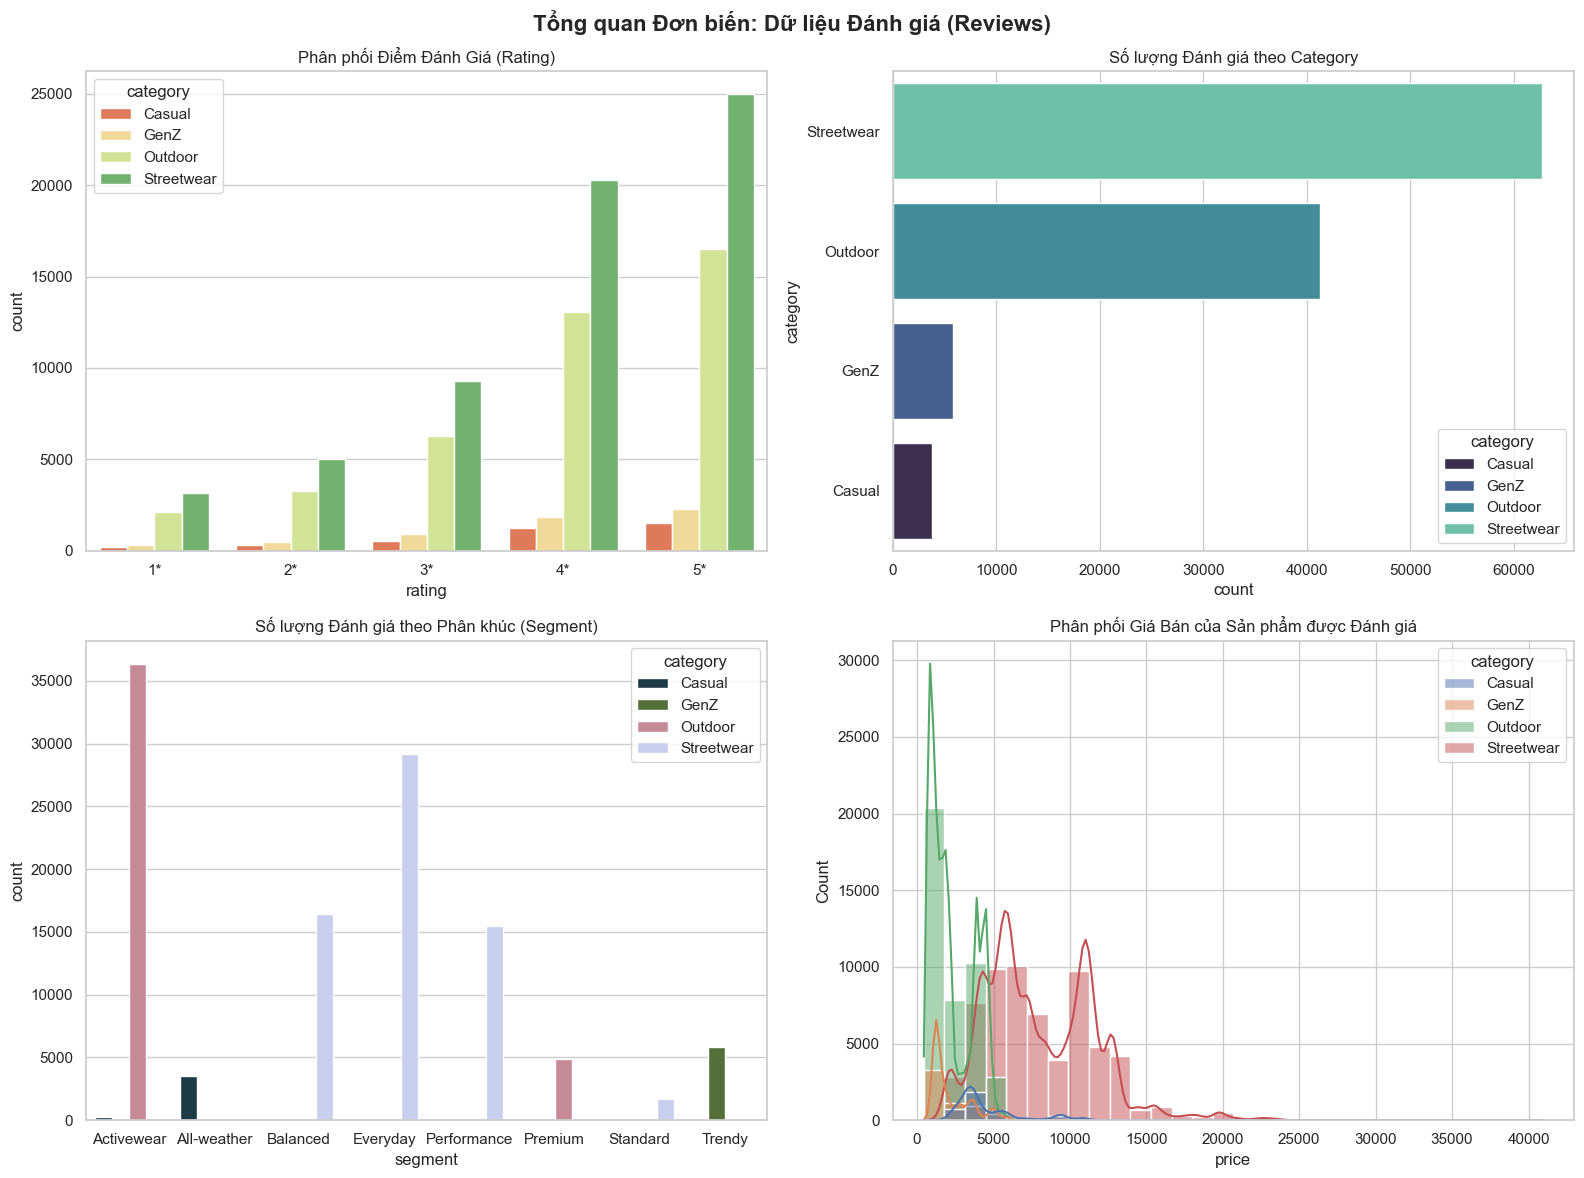

In [ ]:
# Tạo lưới 2x2 cho Reviews - Đơn biến
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tổng quan Đơn biến: Dữ liệu Đánh giá (Reviews)', fontsize=16, fontweight='bold')

# 1. Phân phối Rating
sns.countplot(data=df_rev, x='rating', hue='category', legend=True, ax=axes[0, 0], palette='RdYlGn')
axes[0, 0].set_title('Phân phối Điểm Đánh Giá (Rating)')

# 2. Phân phối Số lượng Đánh giá theo Category
sns.countplot(data=df_rev, y='category', hue='category', legend=True, ax=axes[0, 1], palette='mako', order=df_rev['category'].value_counts().index)
axes[0, 1].set_title('Số lượng Đánh giá theo Category')

# 3. Phân phối Số lượng Đánh giá theo Phân khúc (Segment)
sns.countplot(data=df_rev, x='segment', hue='category', legend=True, ax=axes[1, 0], palette='cubehelix')
axes[1, 0].set_title('Số lượng Đánh giá theo Phân khúc (Segment)')

# 4. Phân phối Giá bán của những sản phẩm được review
sns.histplot(data=df_rev, x='price', hue='category', legend=True, bins=30, kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Phân phối Giá Bán của Sản phẩm được Đánh giá')

plt.tight_layout()
plt.show()

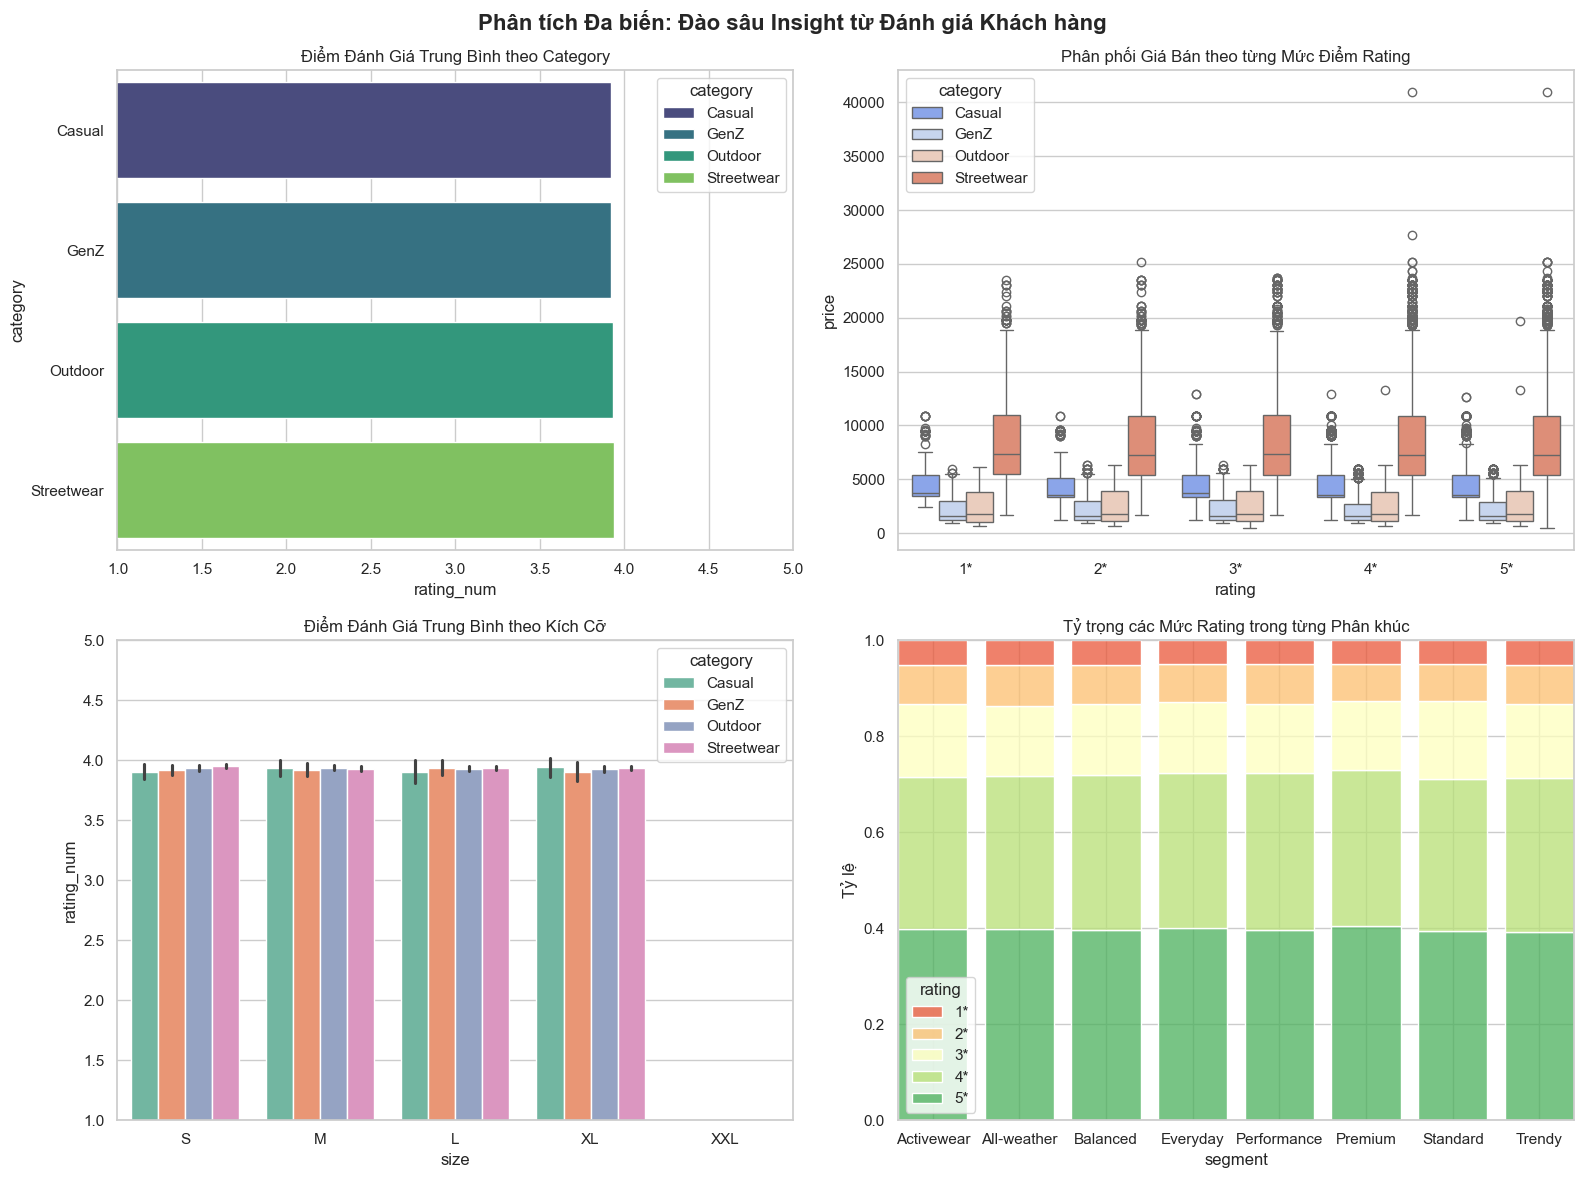

In [ ]:
# Đảm bảo rating là dạng số
# Tạo lưới 2x2 cho Reviews - Đa biến
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Đa biến: Đào sâu Insight từ Đánh giá Khách hàng', fontsize=16, fontweight='bold')

# 1. Barplot: Rating trung bình theo Category
sns.barplot(data=df_rev, y='category', x='rating_num', hue='category', legend=True, ax=axes[0, 0], palette='viridis', errorbar=None)
axes[0, 0].set_xlim(1, 5) # Rating chỉ từ 1 đến 5
axes[0, 0].set_title('Điểm Đánh Giá Trung Bình theo Category')

# 2. Boxplot: Giá sản phẩm (Price) ảnh hưởng thế nào đến Rating?
# Xem khách hàng mua đồ đắt tiền có khắt khe hơn không
sns.boxplot(data=df_rev, x='rating', y='price', hue='category', legend=True, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Phân phối Giá Bán theo từng Mức Điểm Rating')

# 3. Điểm Rating trung bình theo Kích cỡ (Size)
sns.barplot(data=df_rev, x='size', y='rating_num', hue='category', legend=True, ax=axes[1, 0], palette='Set2', order=['S', 'M', 'L', 'XL', 'XXL'])
axes[1, 0].set_ylim(1, 5)
axes[1, 0].set_title('Điểm Đánh Giá Trung Bình theo Kích Cỡ')

# 4. Tỷ lệ % các mức Rating trong từng Phân khúc (Stacked-like view dùng histplot)
sns.histplot(data=df_rev, x='segment', hue='rating', legend=True, multiple='fill', ax=axes[1, 1], palette='RdYlGn', shrink=0.8)
axes[1, 1].set_title('Tỷ trọng các Mức Rating trong từng Phân khúc')
axes[1, 1].set_ylabel('Tỷ lệ')

plt.tight_layout()
plt.show()

### temp

In [ ]:
df_shipping = df_ord.merge(df_ship, on='order_id', how='left')
df_shipping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        646945 non-null  string        
 1   order_date      646945 non-null  datetime64[ns]
 2   customer_id     646945 non-null  string        
 3   zip             646945 non-null  string        
 4   order_status    646945 non-null  category      
 5   payment_method  646945 non-null  category      
 6   device_type     646945 non-null  category      
 7   order_source    646945 non-null  category      
 8   payment_value   646945 non-null  float64       
 9   installments    646945 non-null  category      
 10  ship_date       566067 non-null  datetime64[ns]
 11  delivery_date   566067 non-null  datetime64[ns]
 12  shipping_fee    566067 non-null  float64       
dtypes: category(5), datetime64[ns](3), float64(2), string(3)
memory usage: 42.6 MB


In [ ]:
#df_pduct = df_pduct.drop(columns=['price', 'cogs', 'product_name'])
#df_cus = df_cus.drop(columns=['signup_date', 'gender', 'city'])
#df_ord = df_ord.drop(columns=['zip'])
#df_ret = df_ret.drop(columns=['product_id', 'return_id', 'return_date', 'return_quantity'])
#df_rev = df_rev.drop(columns=['product_id', 'customer_id', 'review_id', 'review_date'])

#df_cus_expe = df_ord.merge(df_cus, on='customer_id', how='left')
#df_cus_expe = df_cus_expe.merge(df_ret, on='order_id', how='left')
#df_cus_expe = df_cus_expe.merge(df_rev, on='order_id', how='left')
#df_cus_expe = df_cus_expe.merge(df_pduct, on='product_id', how='left')
#df_cus_expe.info()

In [ ]:
for col in df_cus_expe.columns:
    if df_cus_expe[col].isna().any():
        if pd.api.types.is_float_dtype(df_cus_expe[col]):
            df_cus_expe[col] = df_cus_expe[col].fillna(0.0)
        elif df_cus_expe[col].dtype.name == 'category':
            df_cus_expe[col] = df_cus_expe[col].cat.add_categories('None')
            df_cus_expe[col] = df_cus_expe[col].fillna('None')
df_cus_expe.info()
display(df_cus_expe.sample(5))

NameError: name 'df_cus_expe' is not defined